In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_spike_to_avg_distances,
    plot_spike_feature_within_vs_between,
    plot_waveform_dist_kde,
    plot_waveform_dist_scatter,
    plot_waveform_dist_raincloud,
    plot_waveform_dist_sorted_dots,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
SPIKE_FIT_DIR   = config.SPE1_PICKLE_ROOT + '/spike_fit_pickles/'

In [ ]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

## Option A — Within vs between: full distribution (KDE)
All spikes pooled. Shows distributional separation between within-cell and between-cell nRMSE.

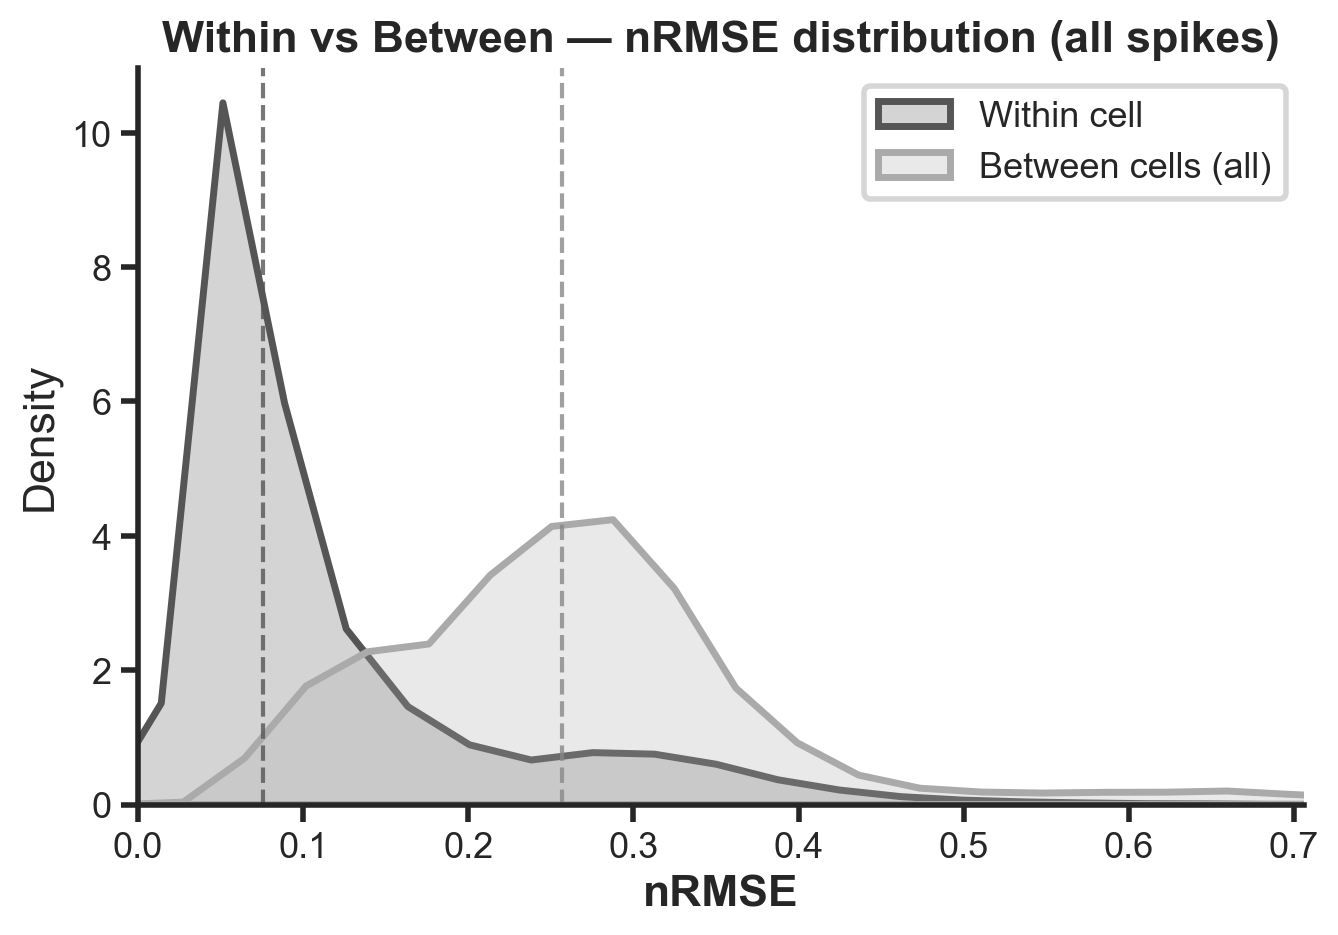

In [ ]:
plot_waveform_dist_kde(df_master, wf_dir=CLUSTER_PKL_DIR, spike_fit_dir=SPIKE_FIT_DIR)

## Option B — Within vs between: raincloud (boxplot + strip)
Same data as A, different view. Unit = spike. Shows median, IQR, and spread.

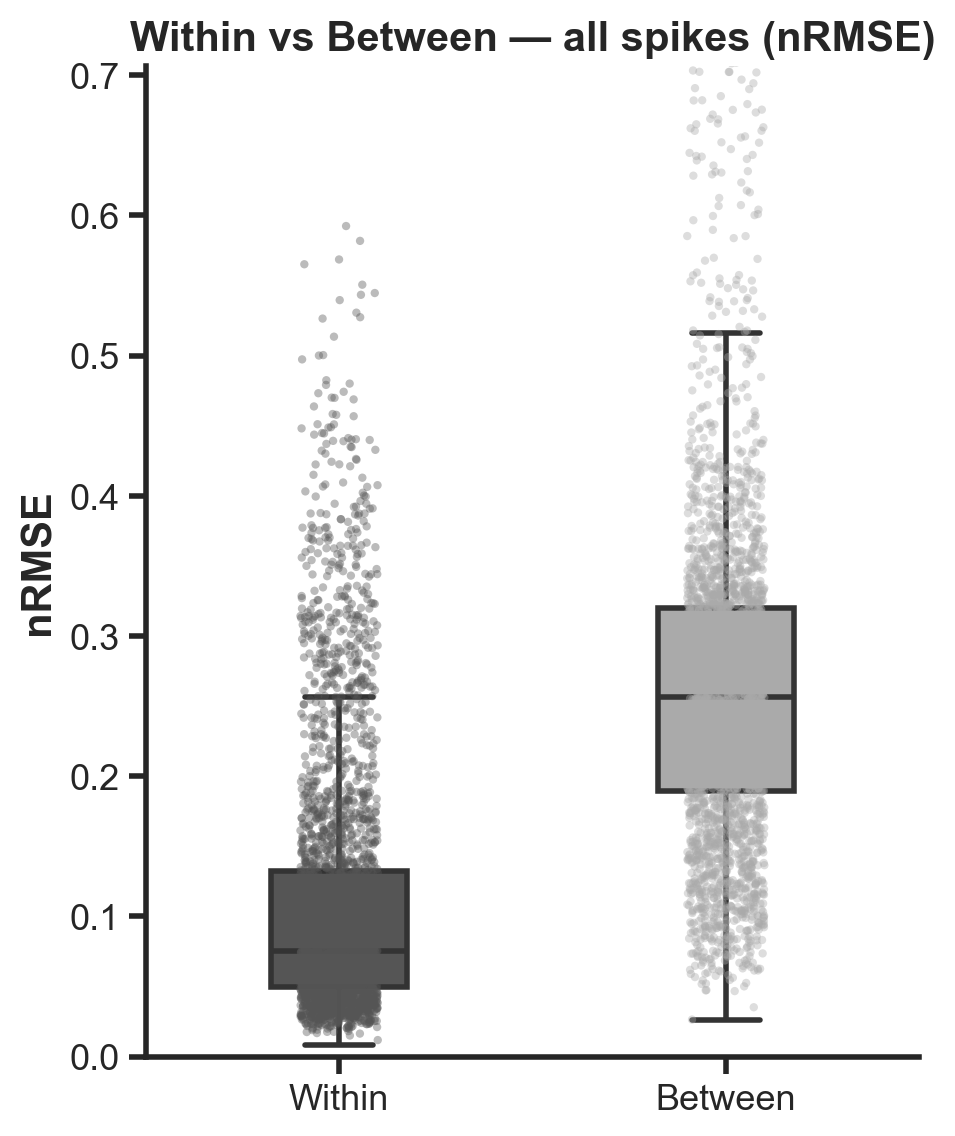

In [ ]:
plot_waveform_dist_raincloud(df_master, wf_dir=CLUSTER_PKL_DIR, spike_fit_dir=SPIKE_FIT_DIR)

## Option C — Per-feature within vs between (simple)
Only cells with clustering for each feature. Within vs between nRMSE per feature as subplots.
Shows that within < between is not just a global pooled result.

[spike_feature_wb] mode=simple  cache=HIT — loading
Loaded waveforms for 43 cells
  peak_amp: loaded from cache
  peak_sharpness: loaded from cache
  peak_width: loaded from cache
  exp_lambda: loaded from cache
  inflection_amp: loaded from cache
  inflection_time: loaded from cache


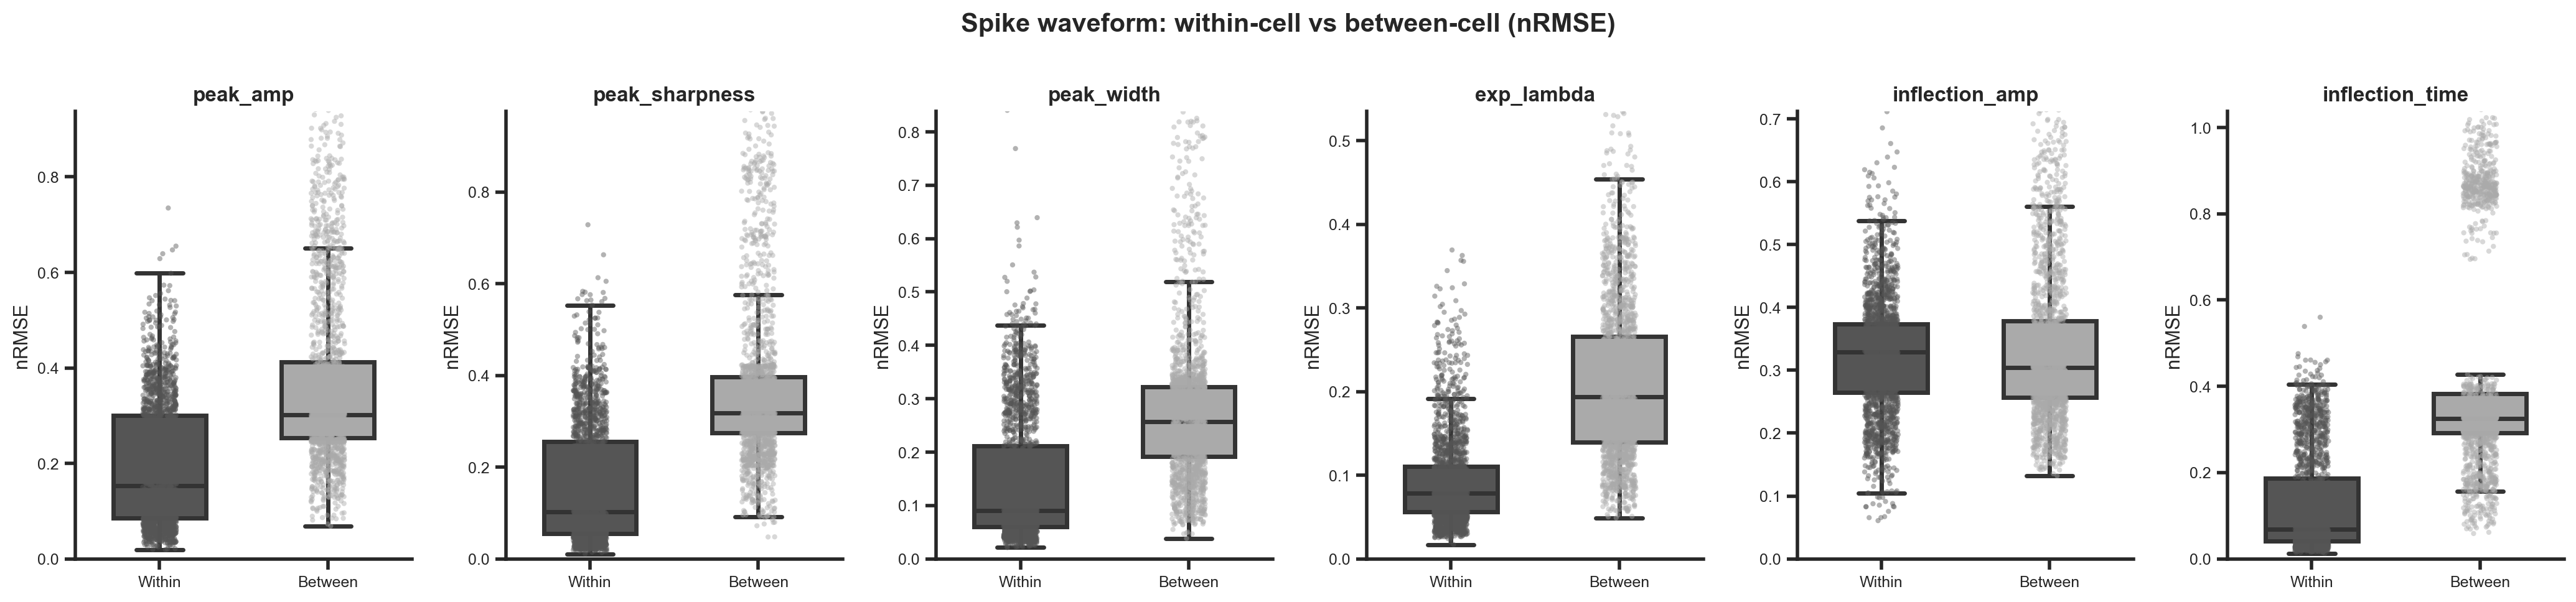

  peak_amp: loaded from cache
  peak_sharpness: loaded from cache
  peak_width: loaded from cache
  exp_lambda: loaded from cache
  inflection_amp: loaded from cache
  inflection_time: loaded from cache


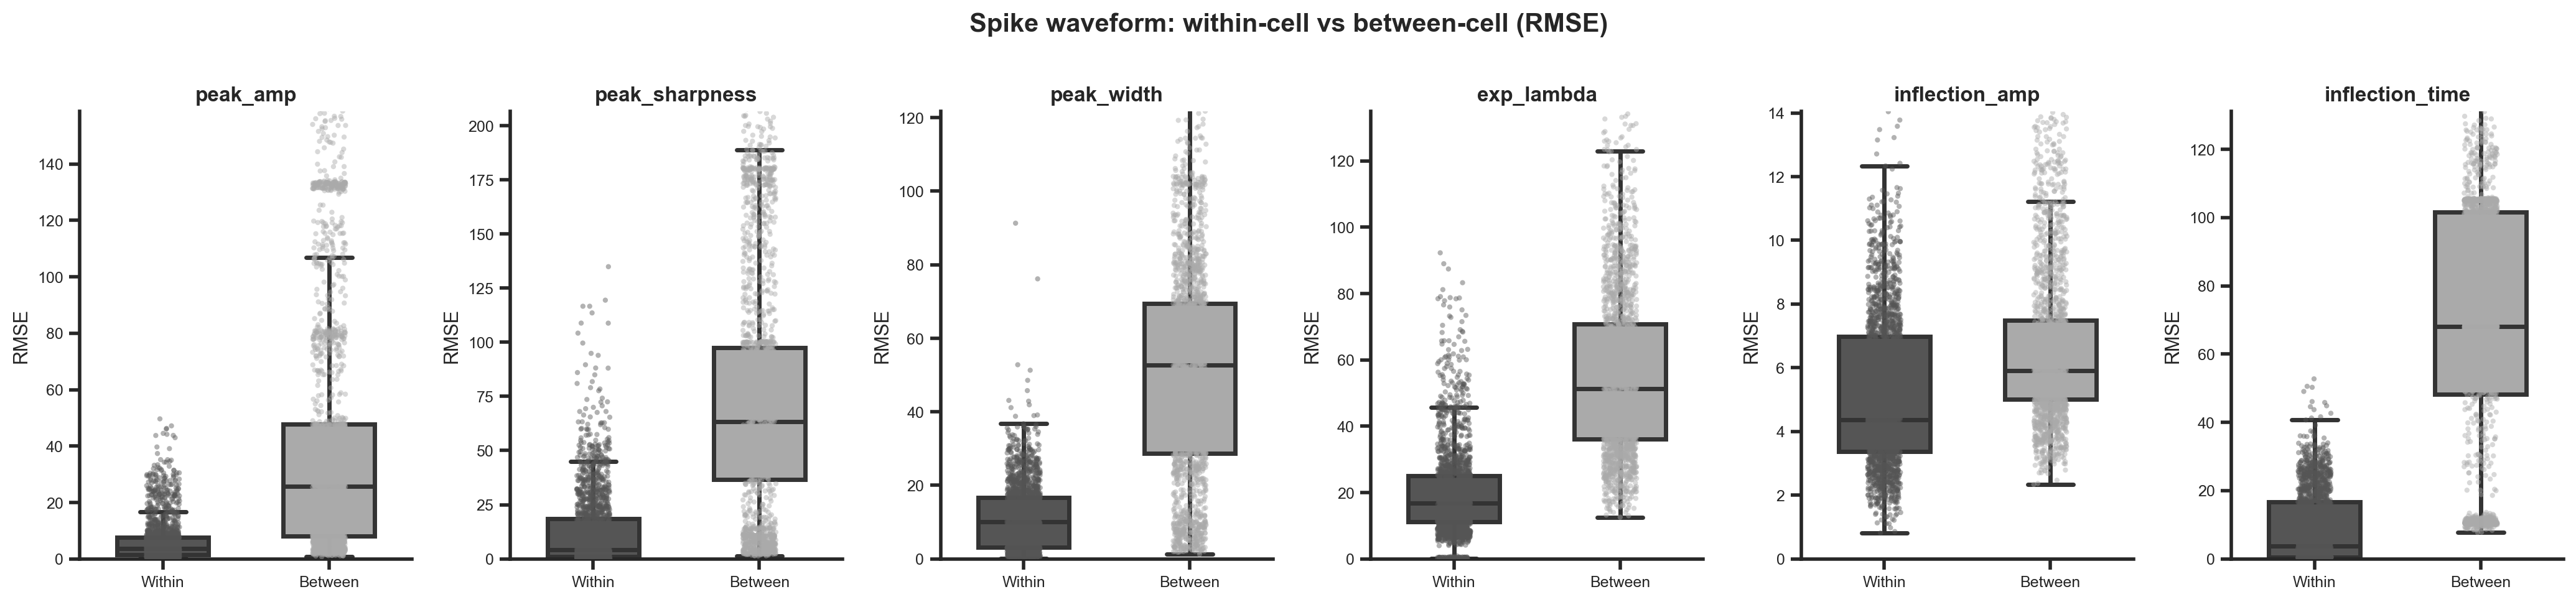

In [ ]:
plot_spike_feature_within_vs_between(CLUSTER_PKL_DIR, SPIKE_FIT_DIR)

## Option D — Per-feature within vs between (detailed: by cell type + patch type)
Same as C but groups broken out by cell type (PC/IN) and patch type (Juxta/WC).
Lets you see whether within < between holds across recording method and cell type.

[spike_feature_wb] mode=detailed  cache=HIT — loading
Loaded waveforms for 43 cells
  peak_amp: loaded from cache


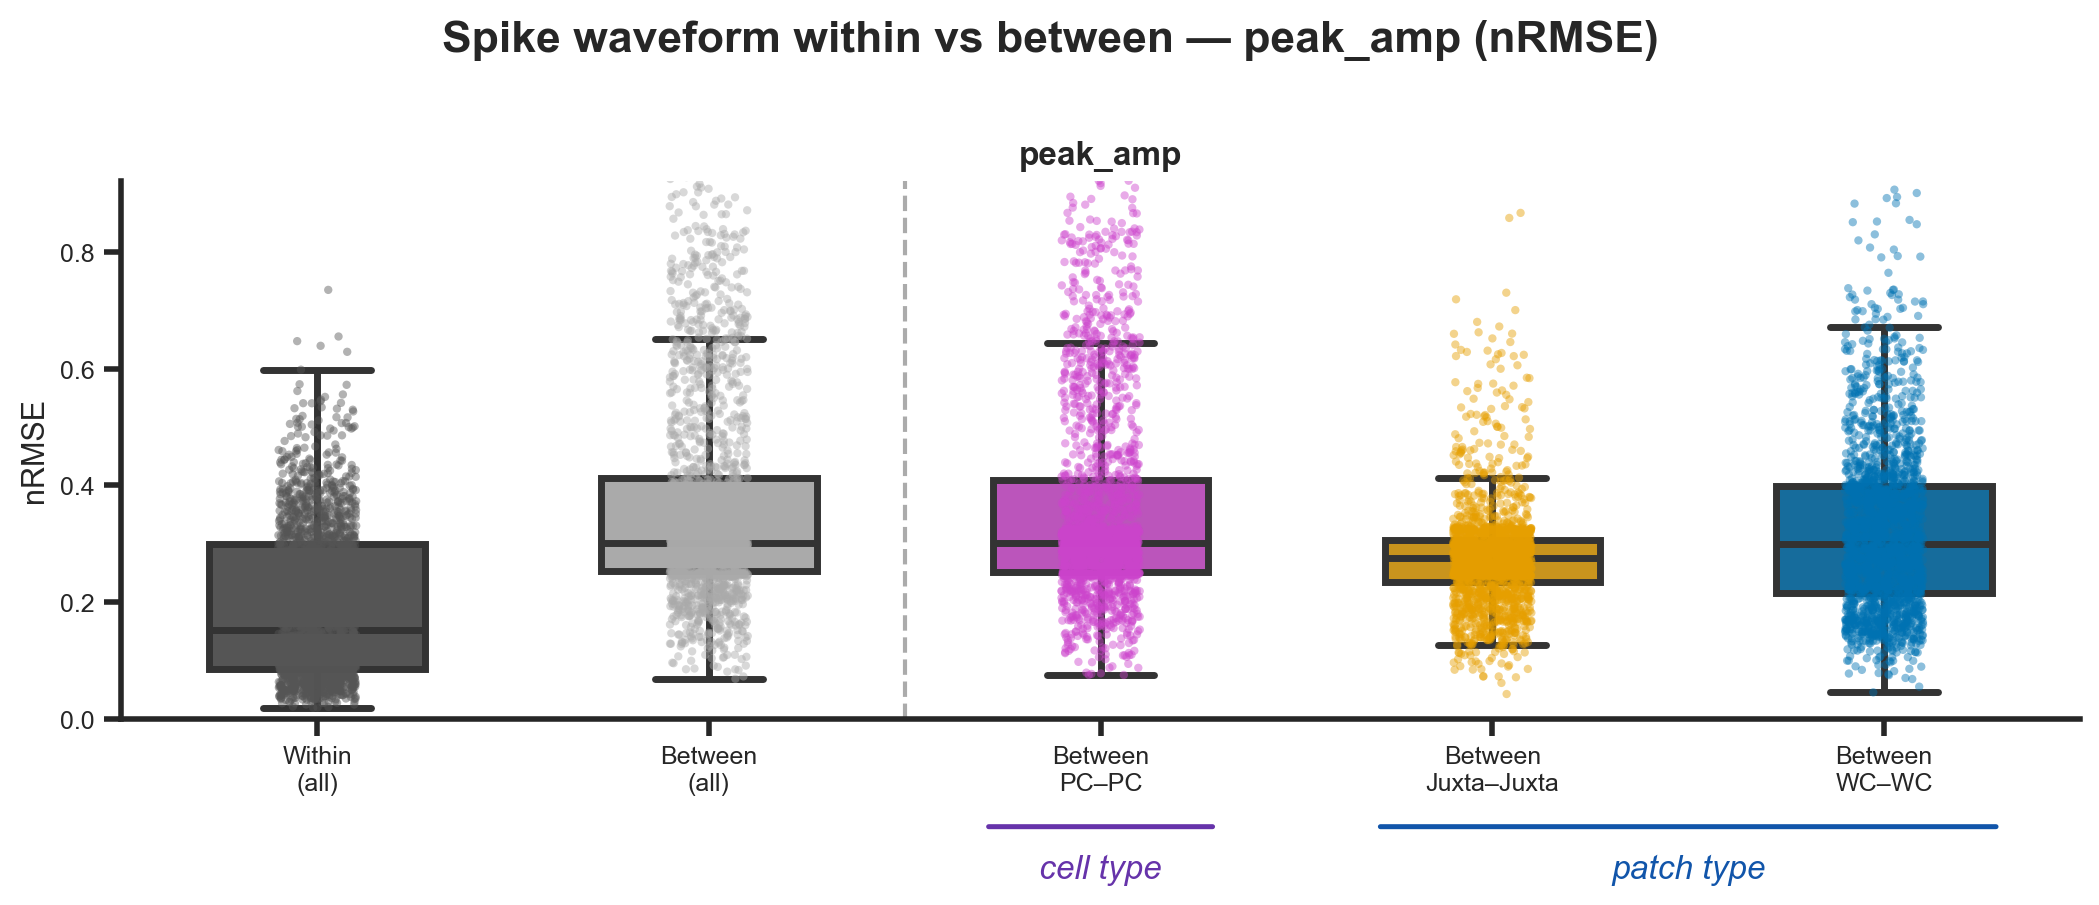

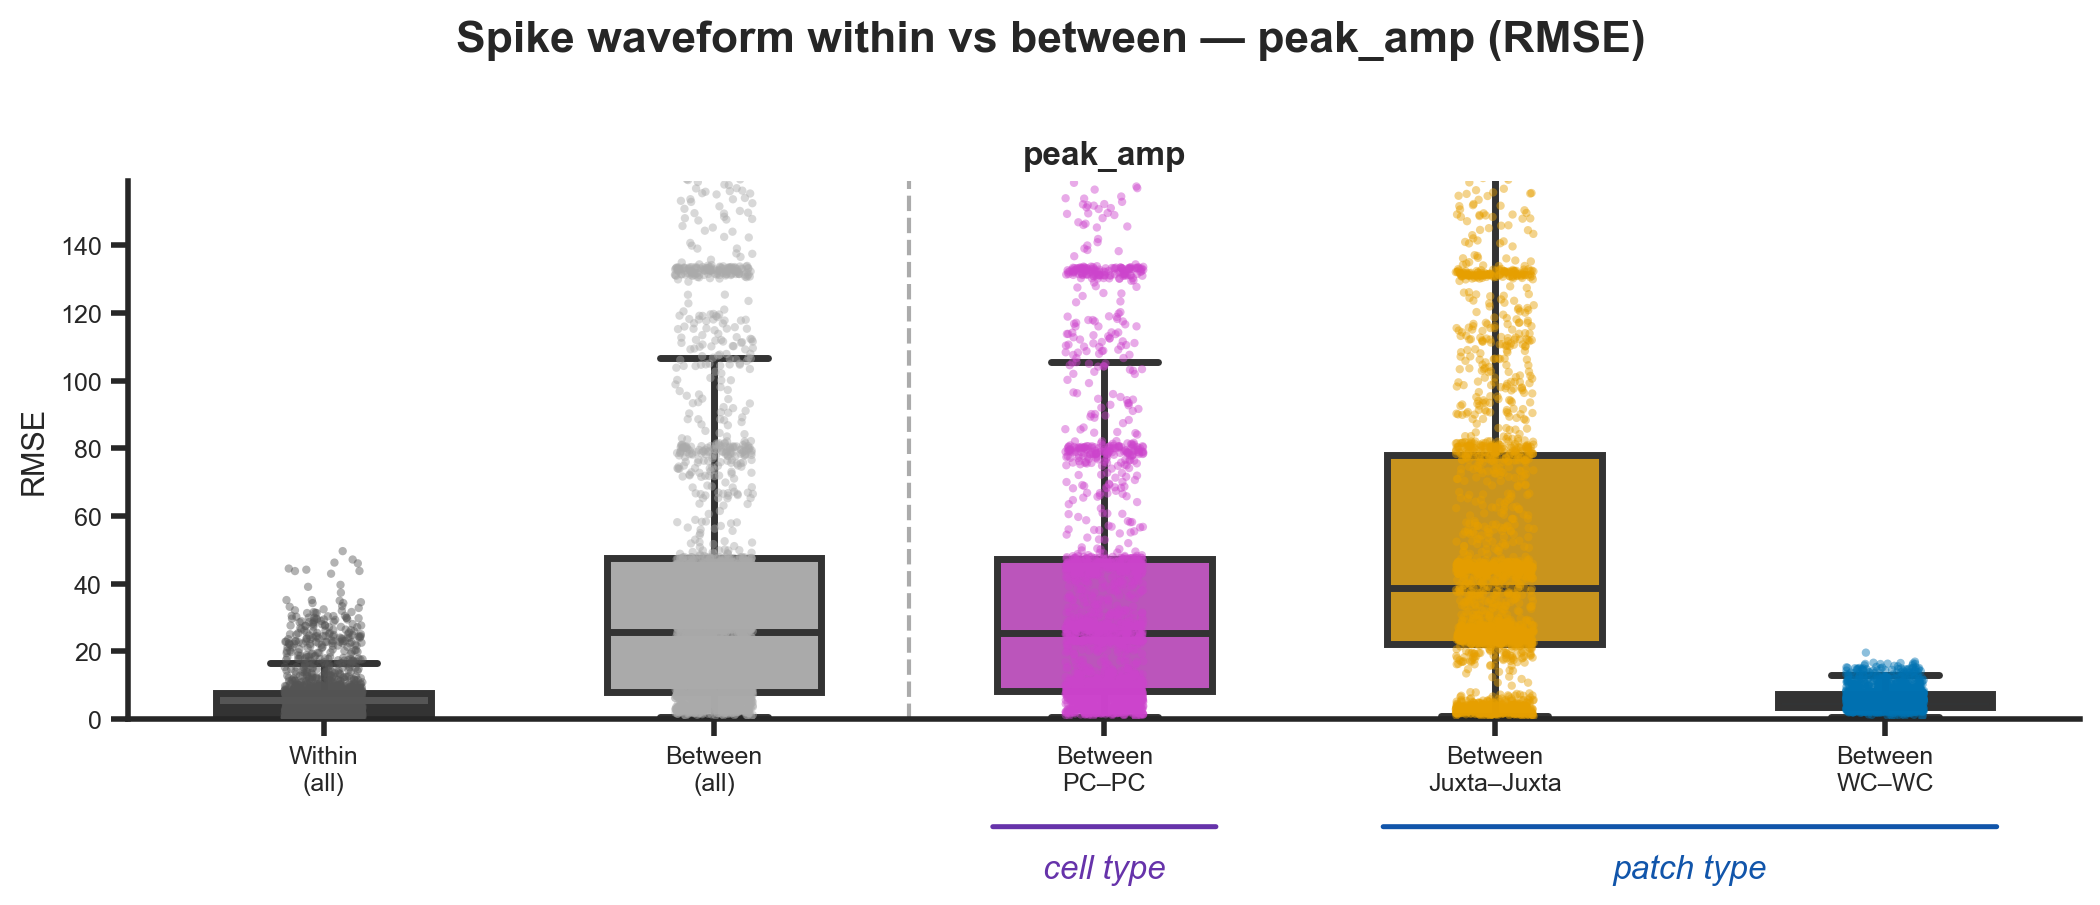

  peak_sharpness: loaded from cache


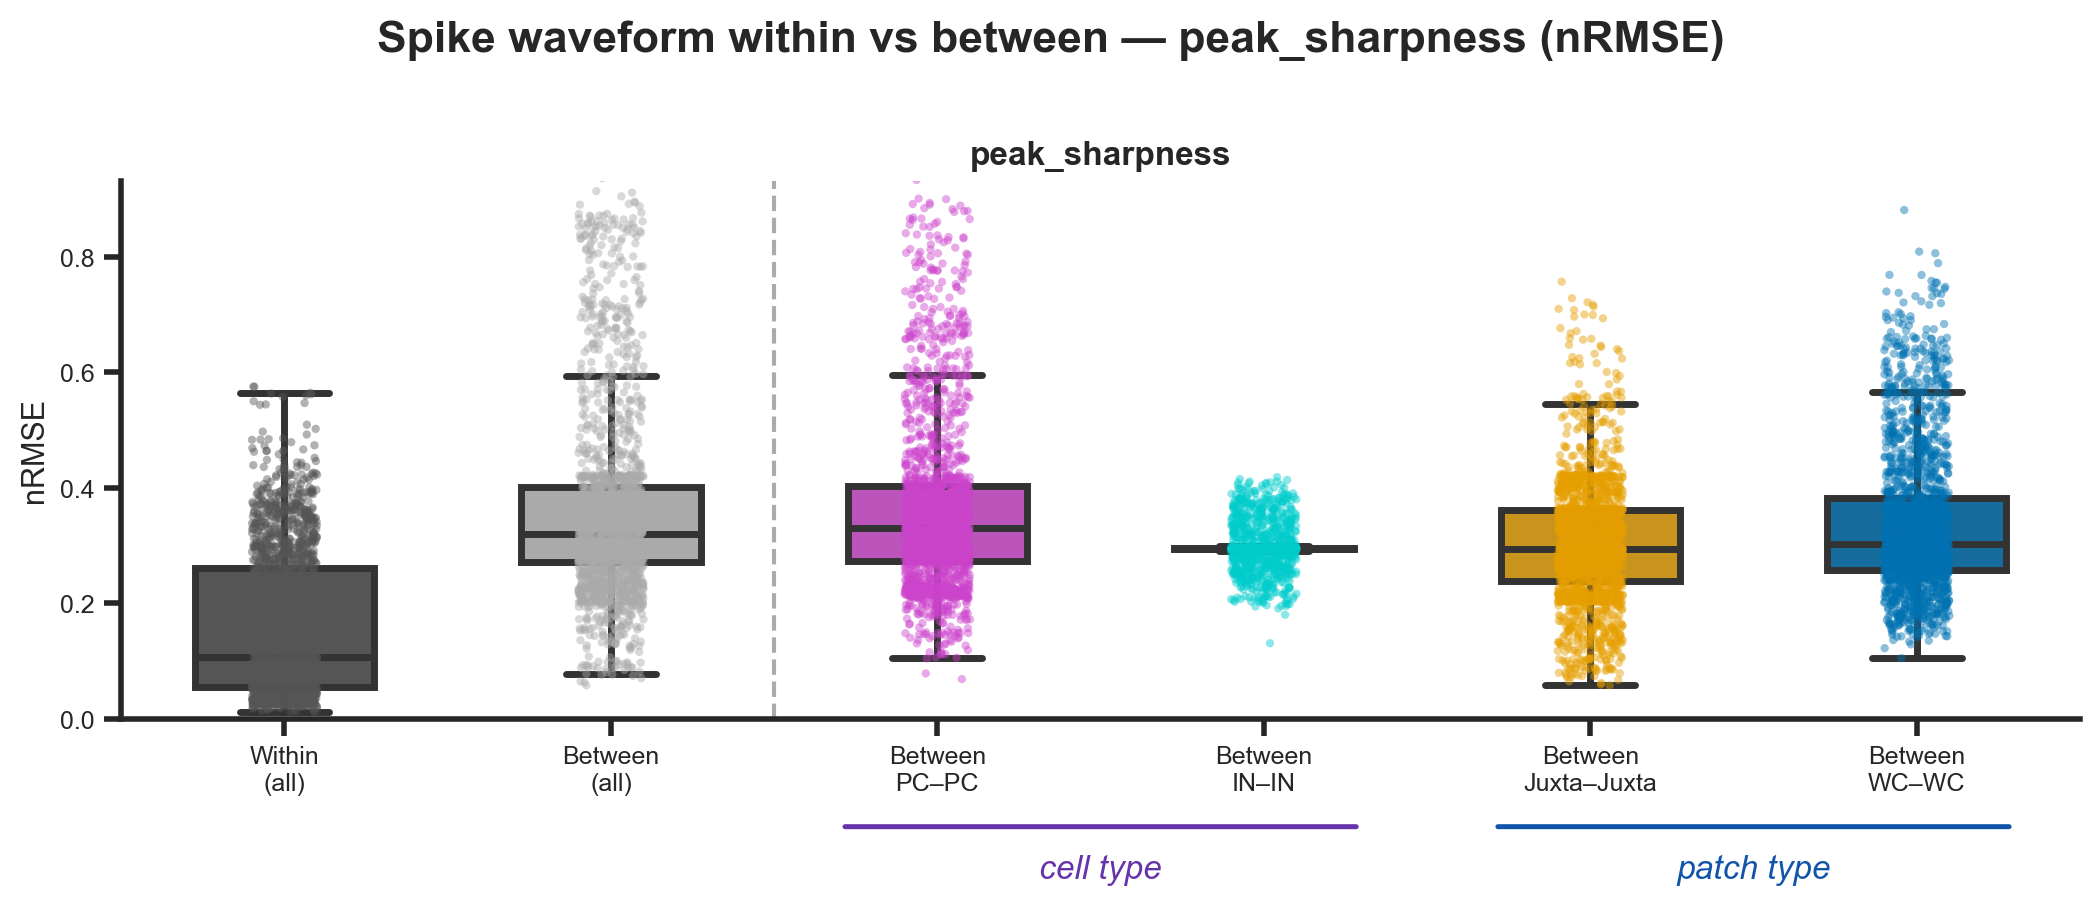

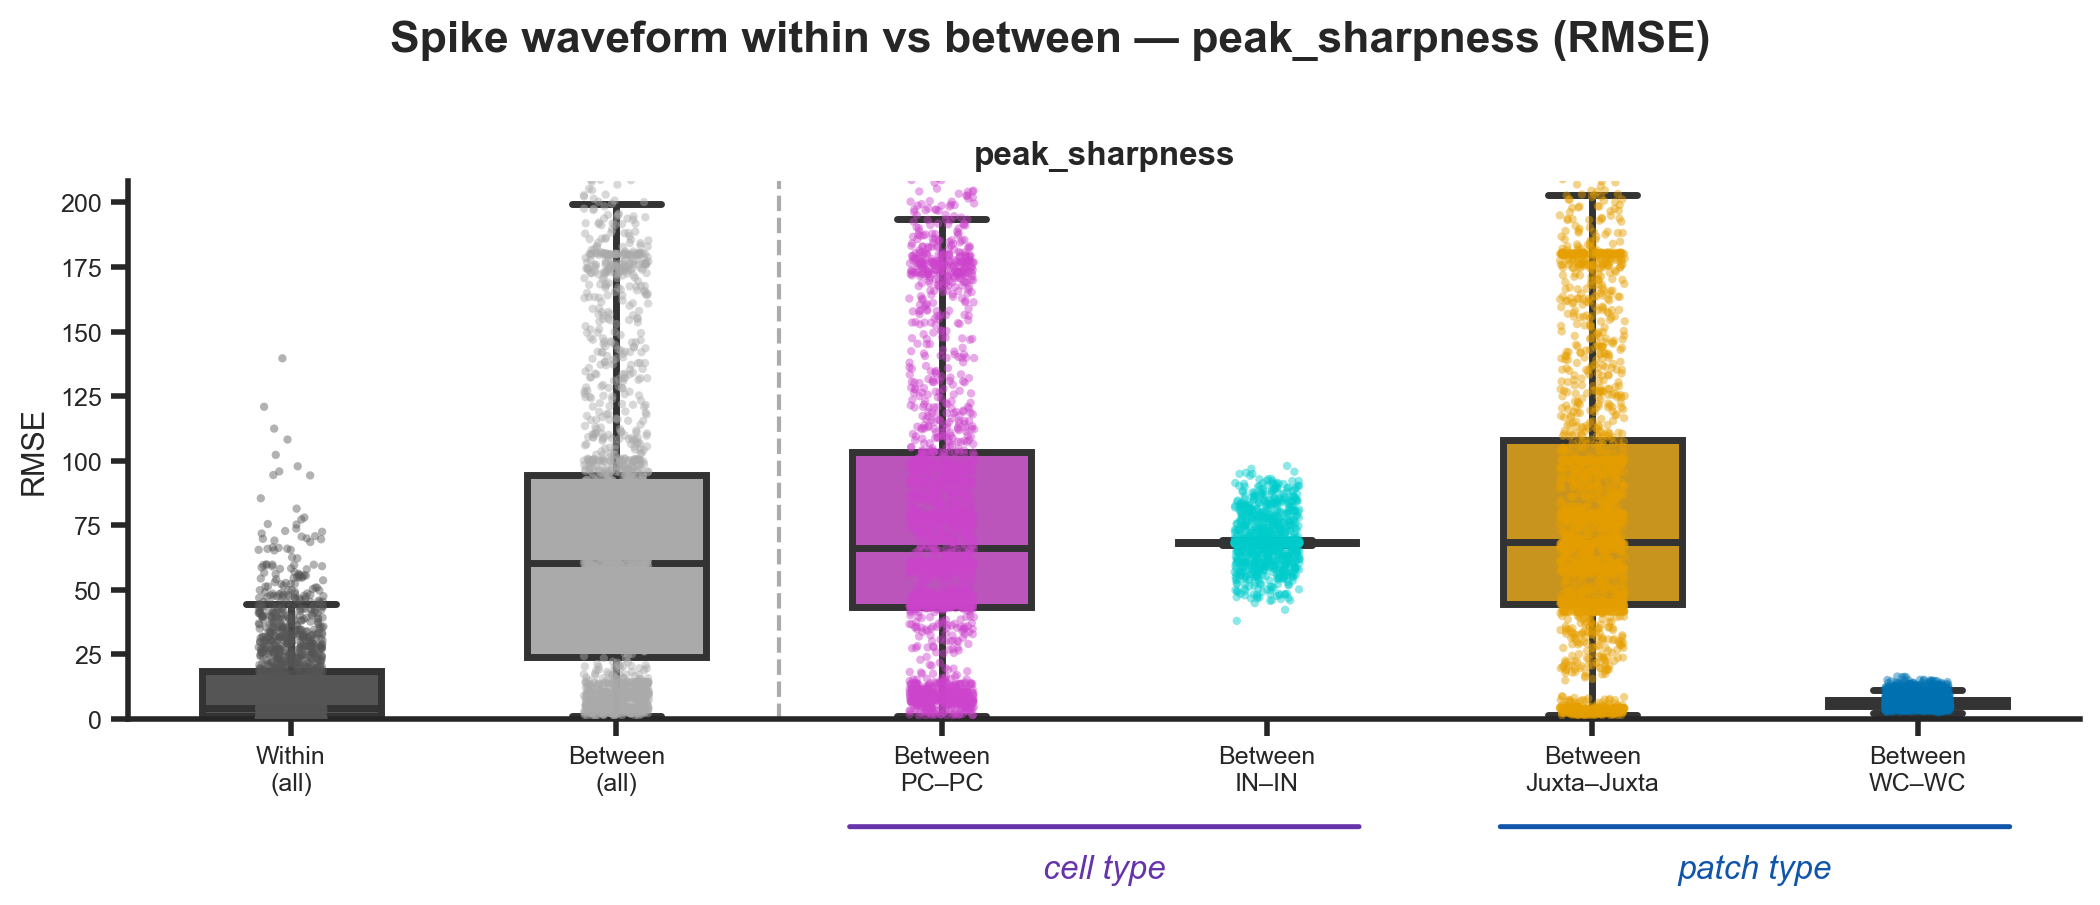

  peak_width: loaded from cache


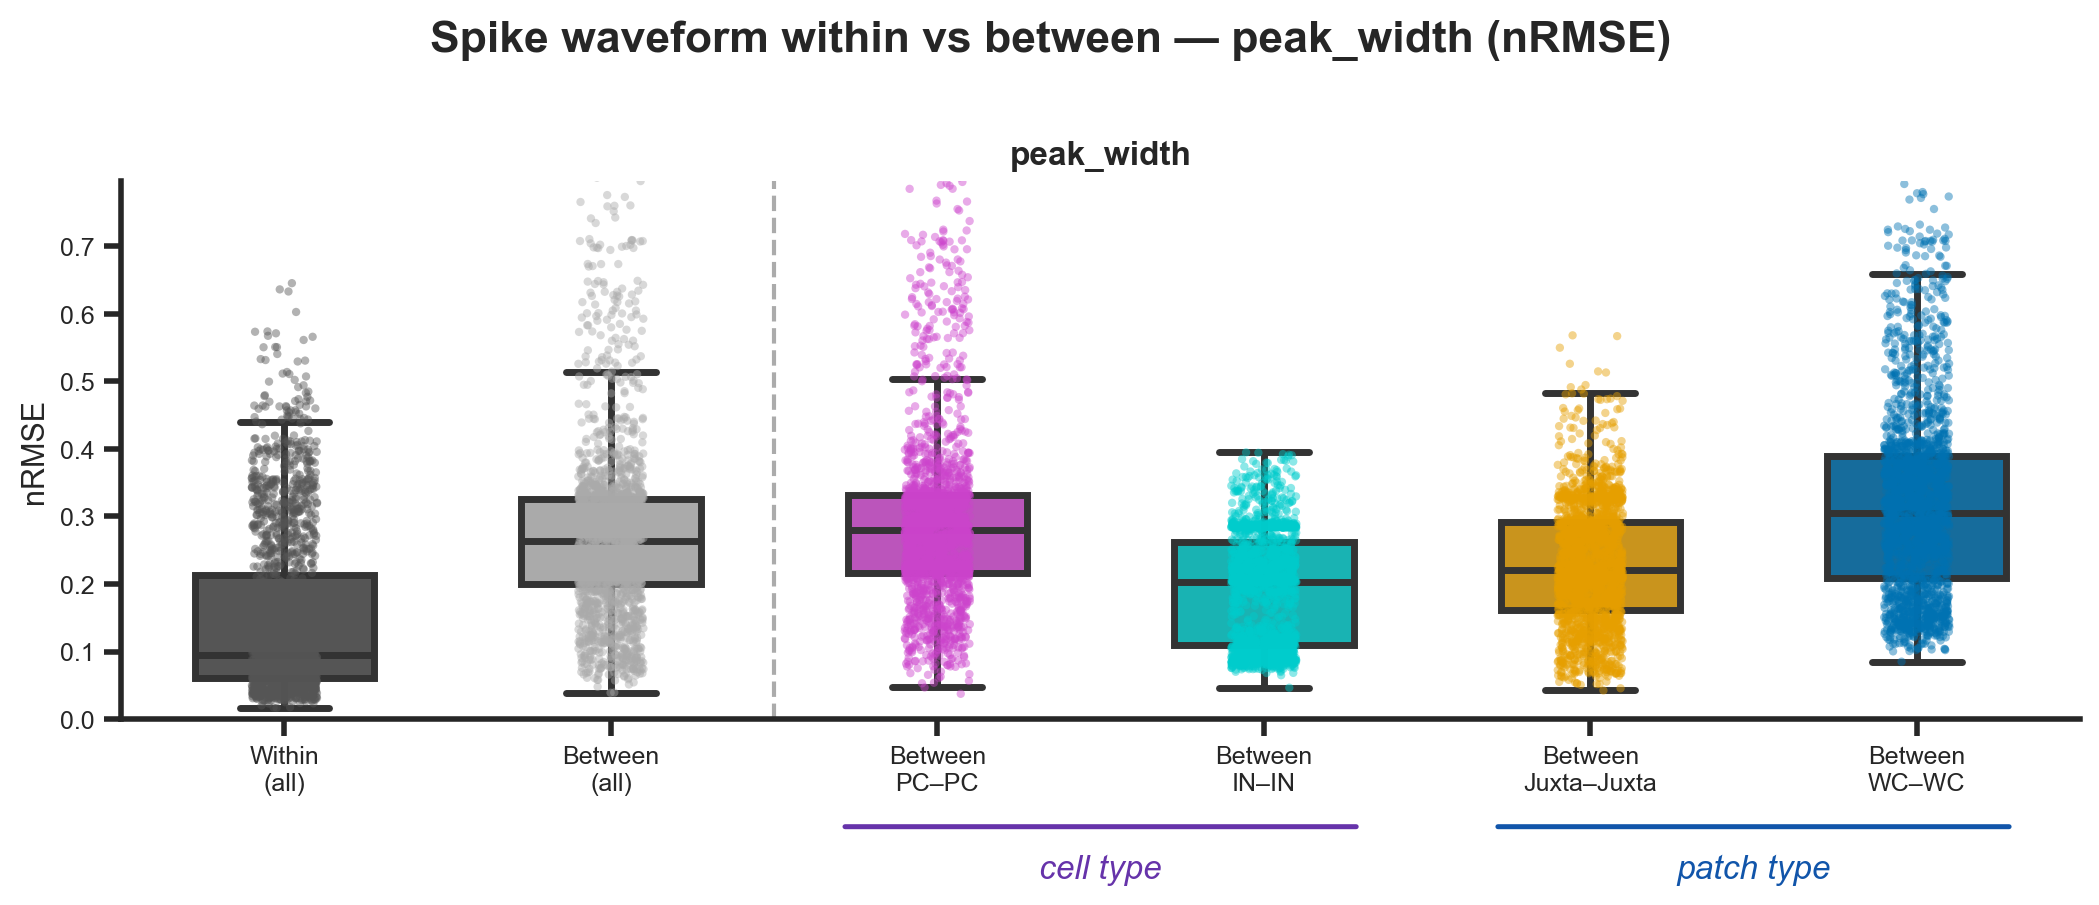

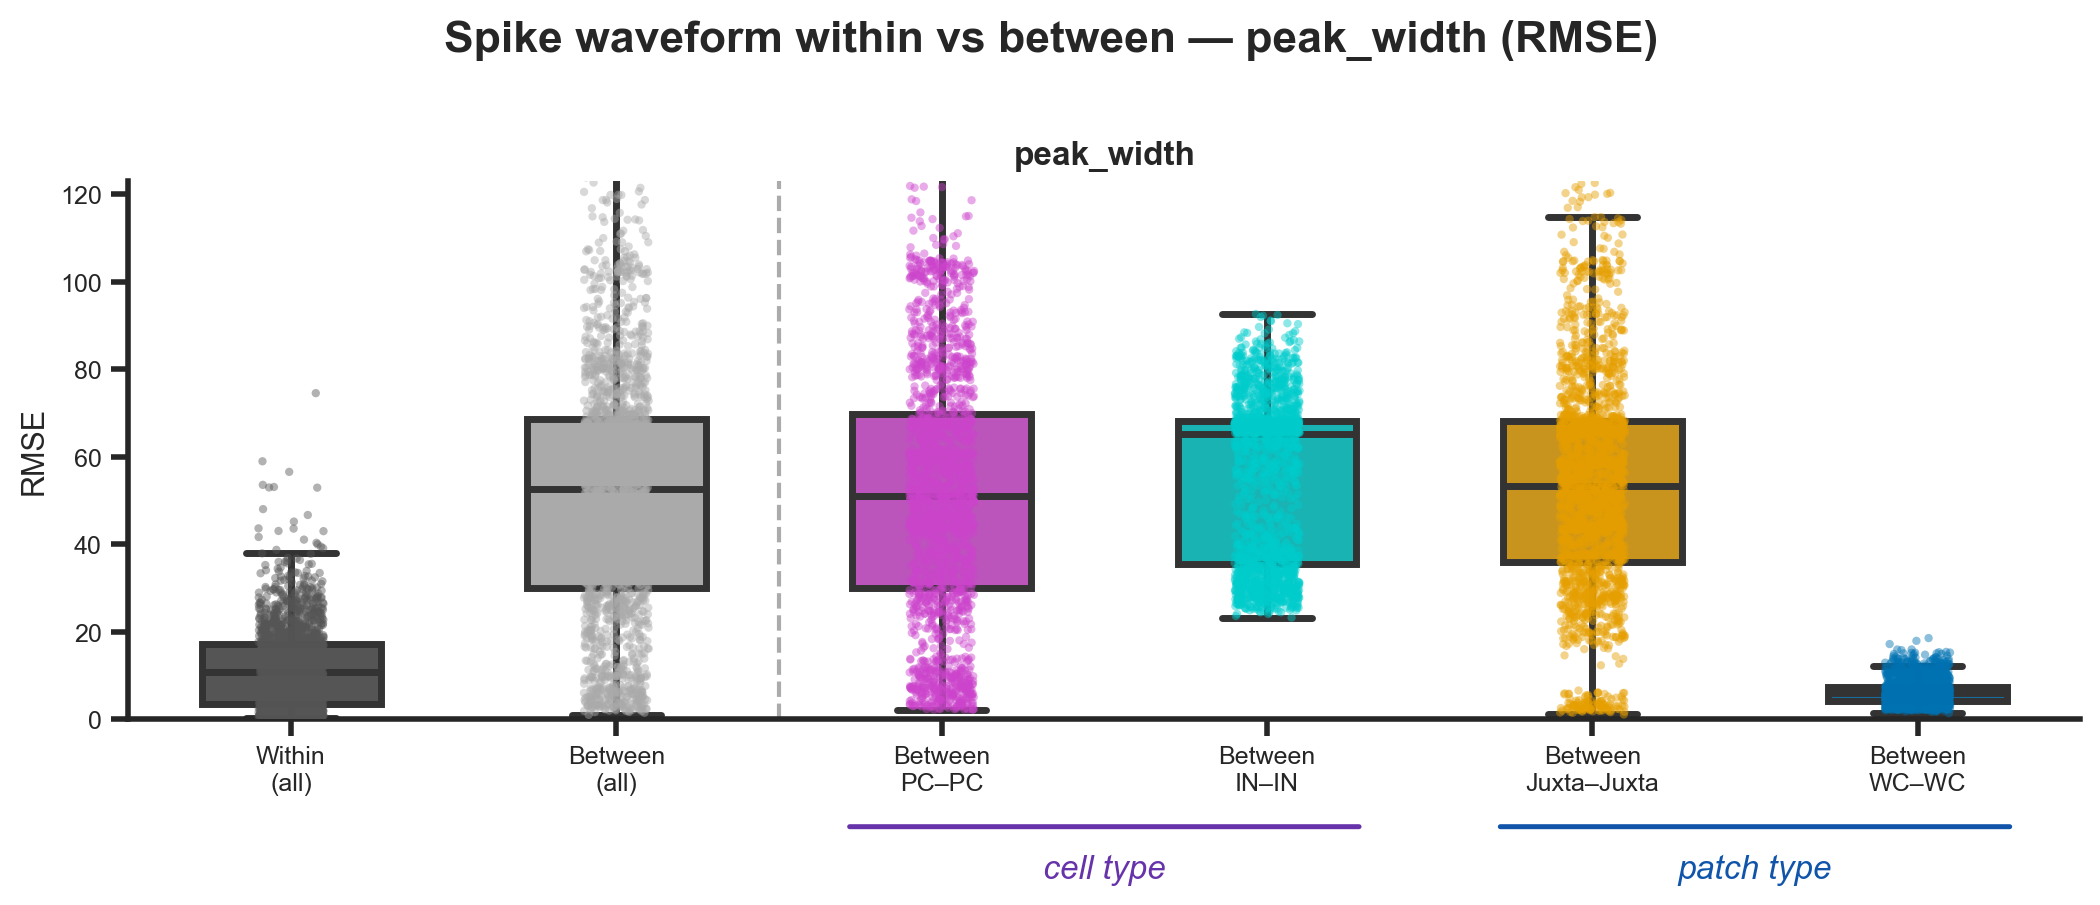

  exp_lambda: loaded from cache


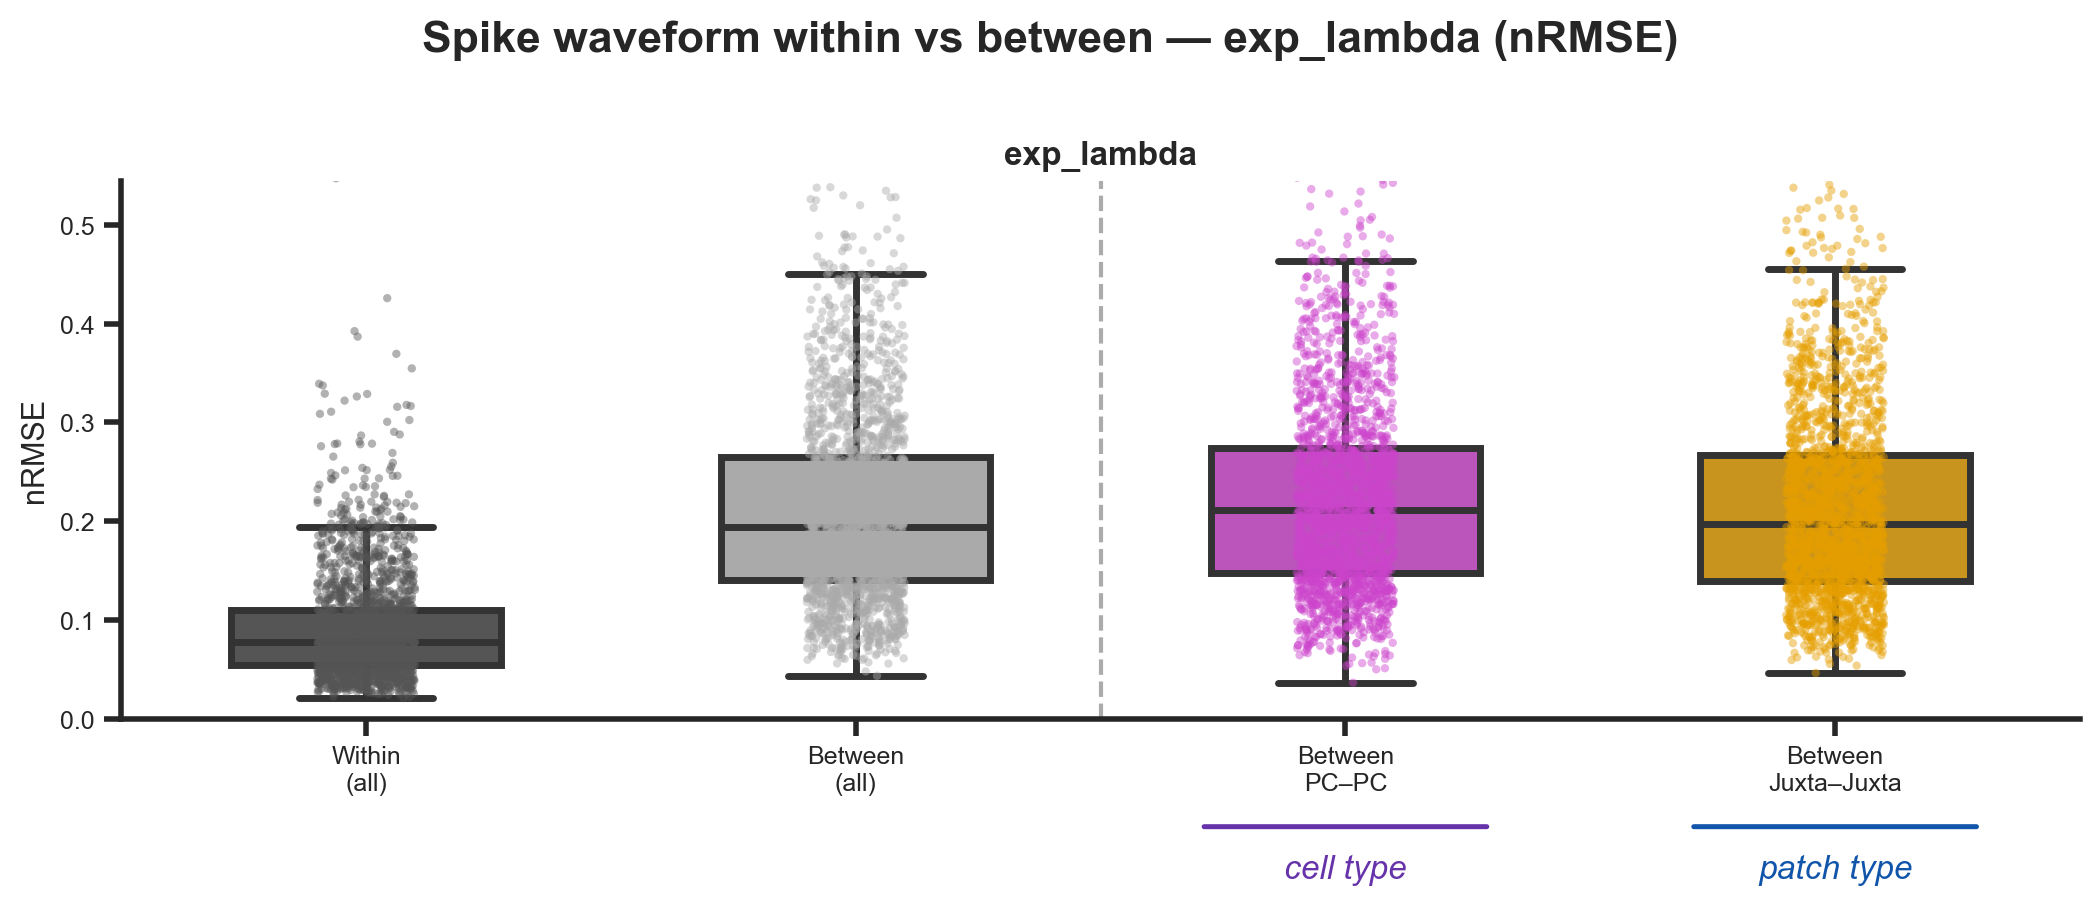

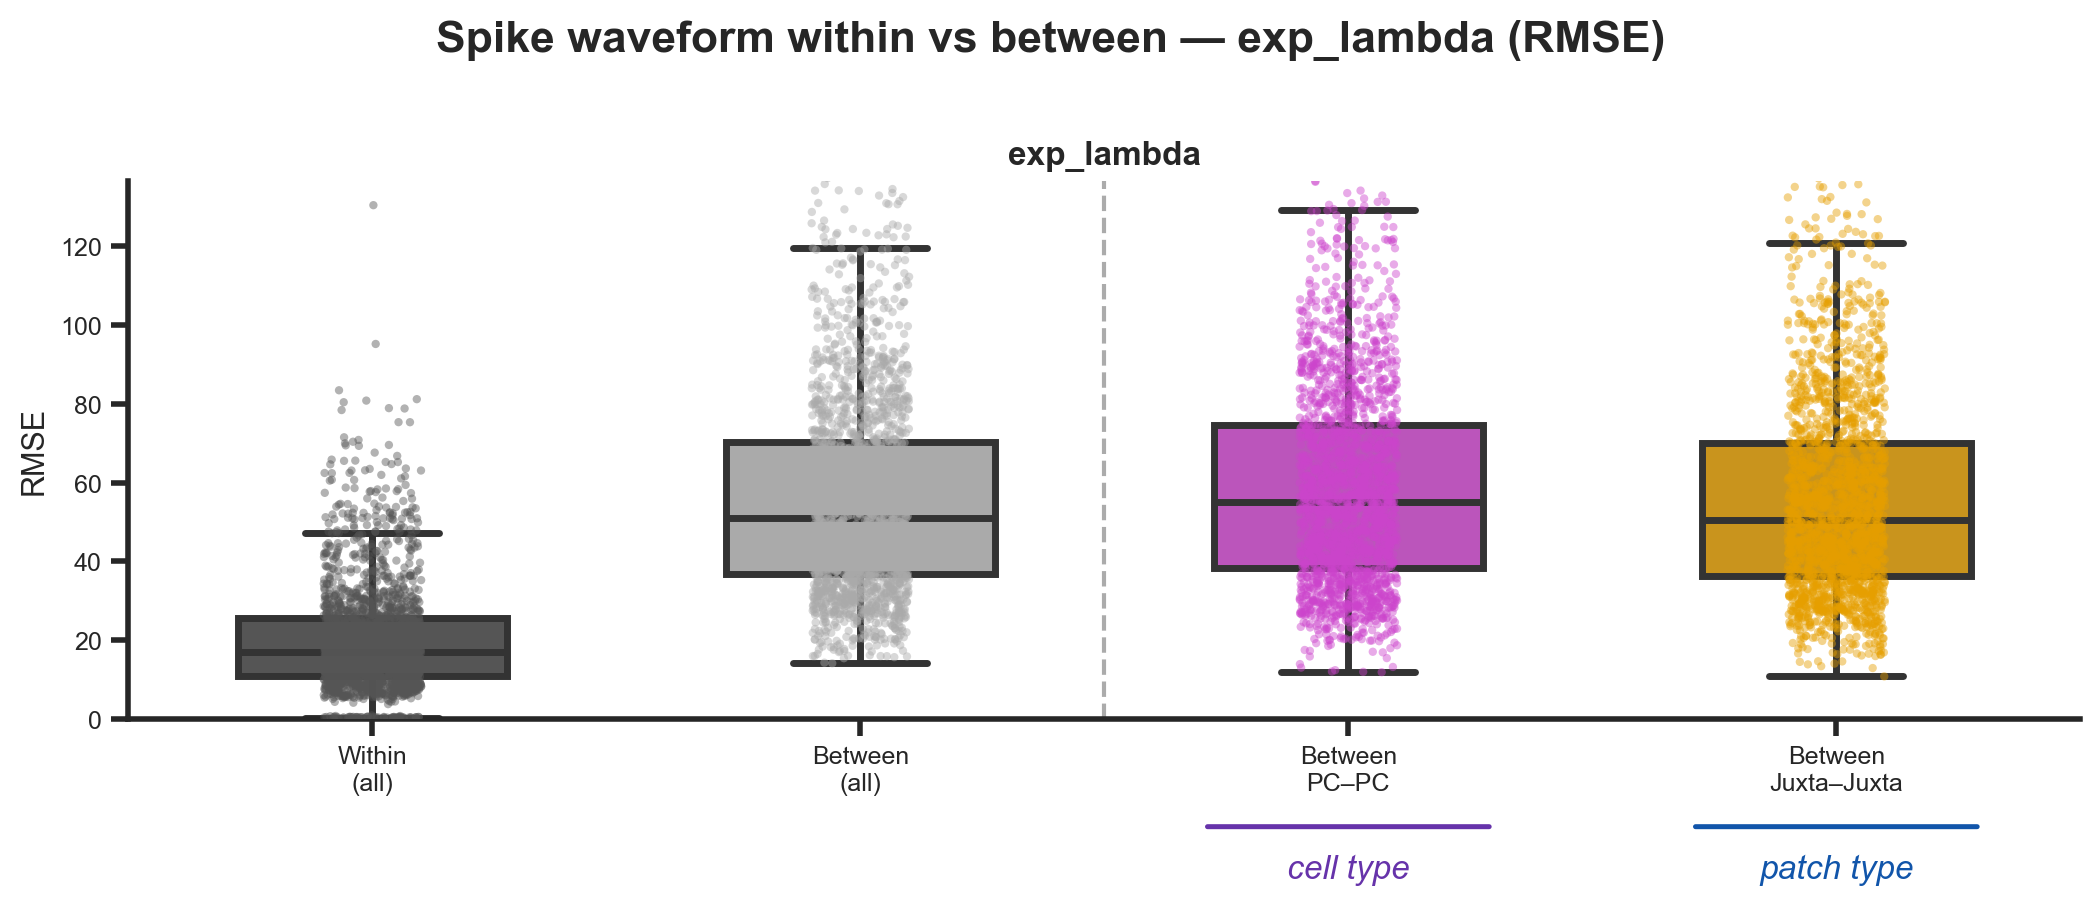

  inflection_amp: loaded from cache


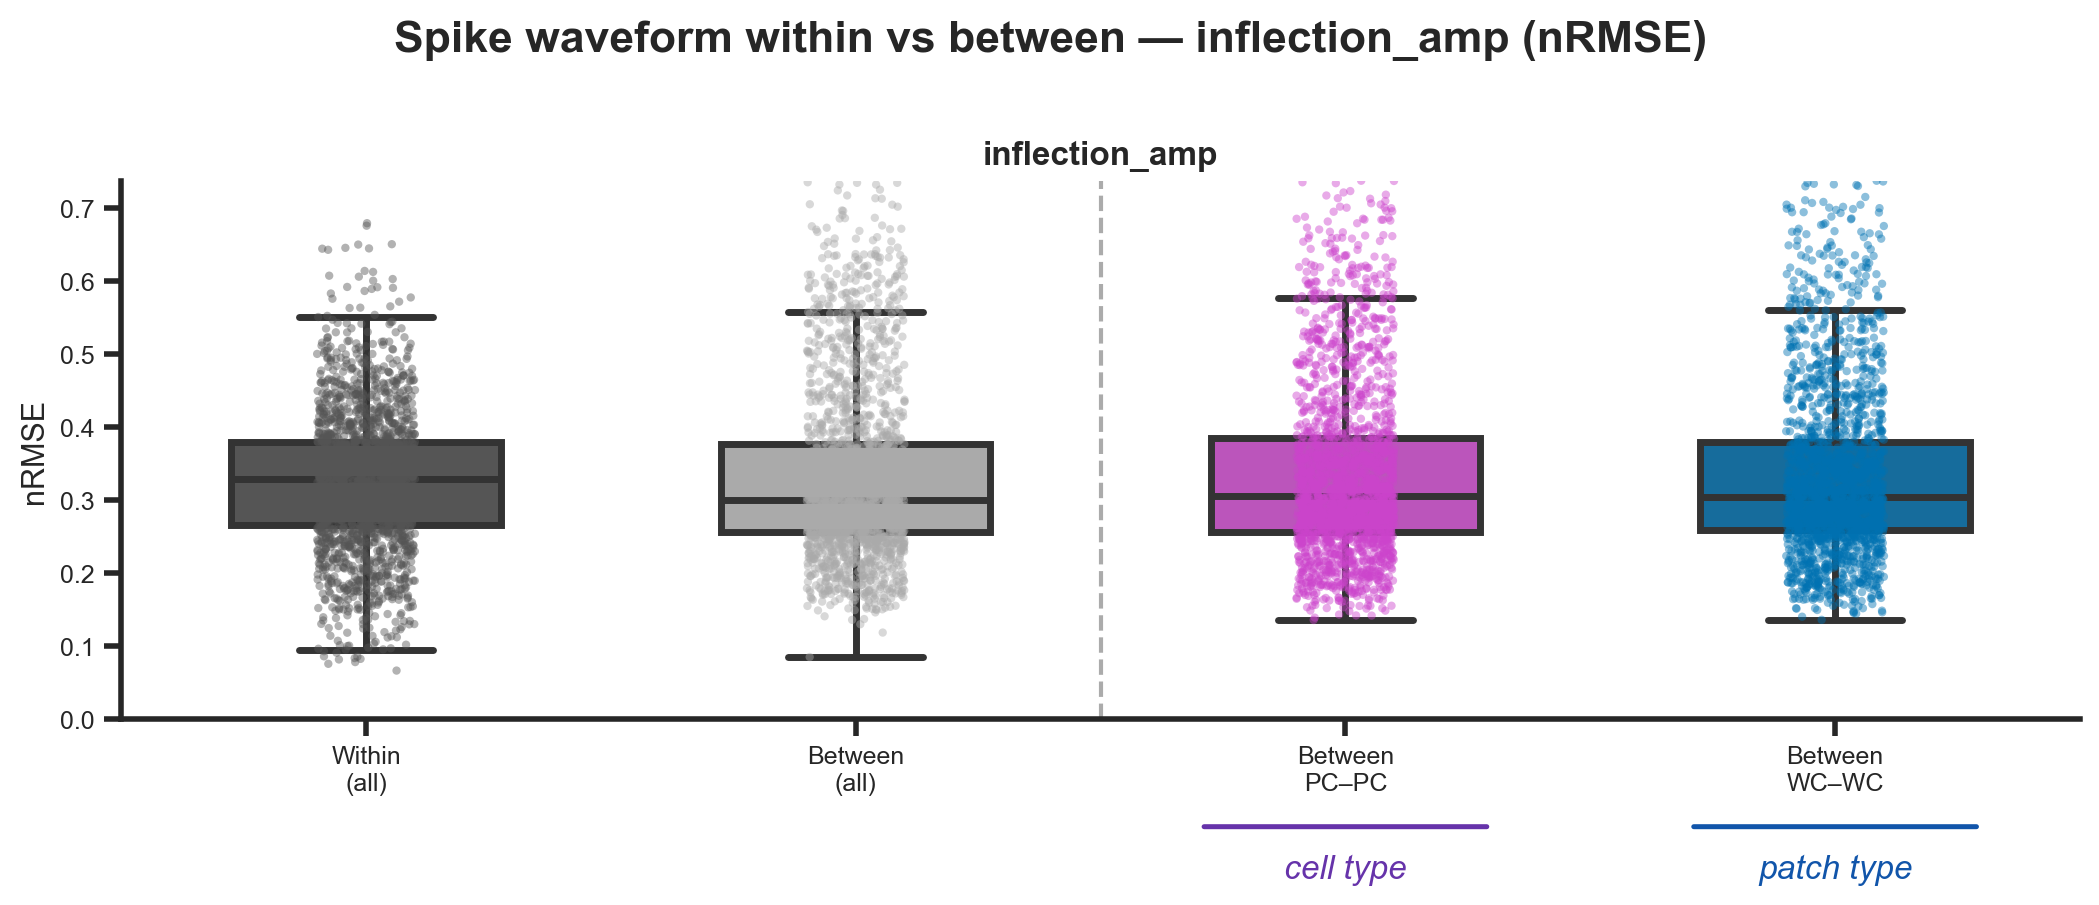

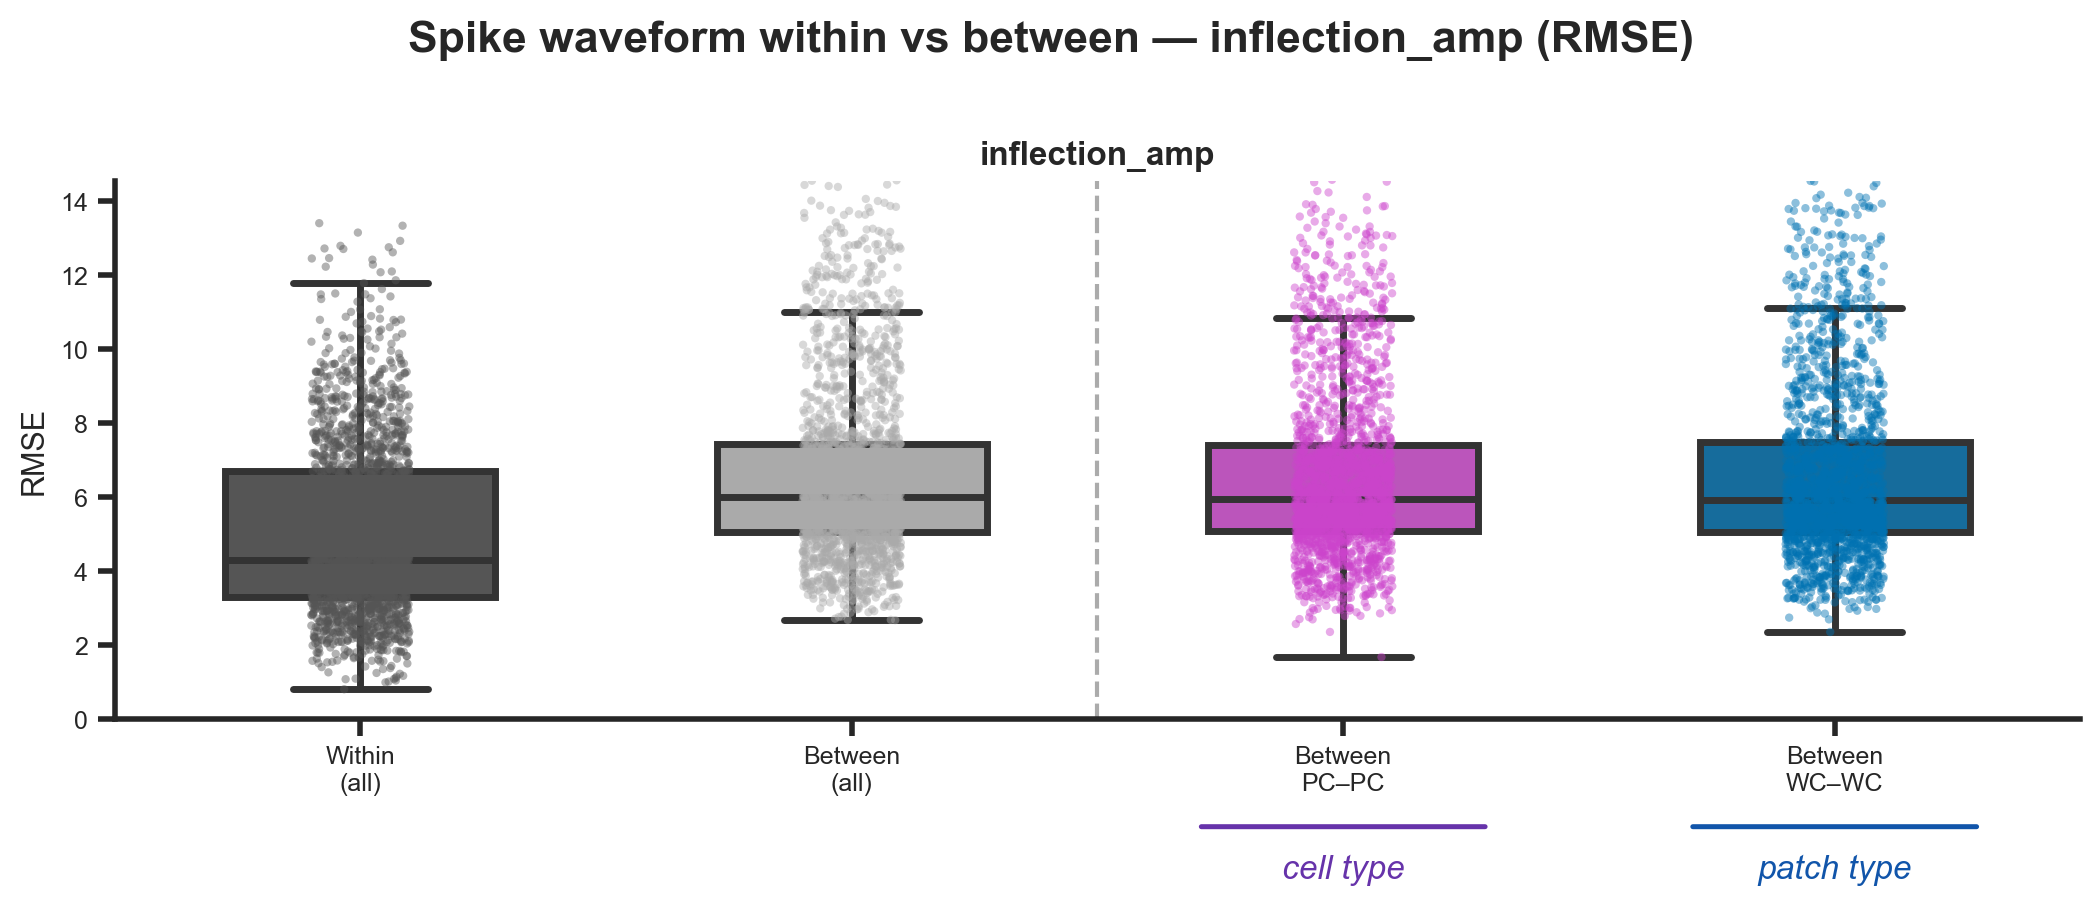

  inflection_time: loaded from cache


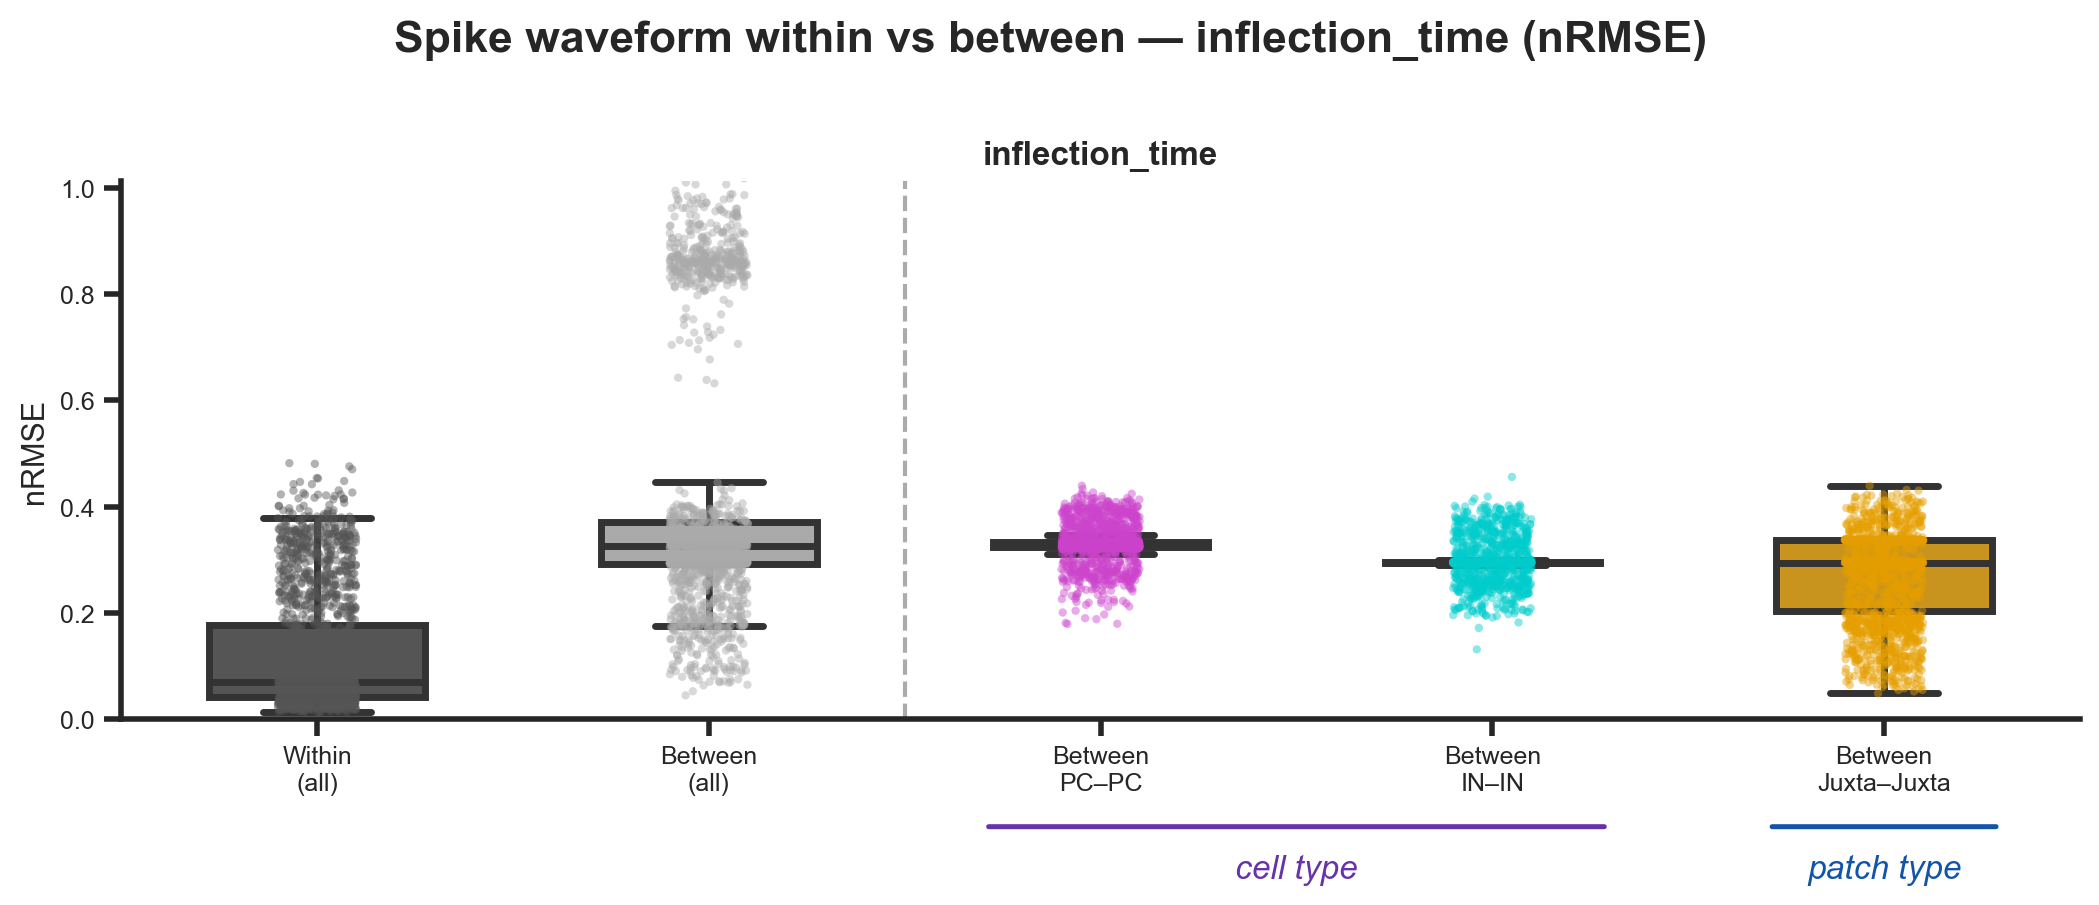

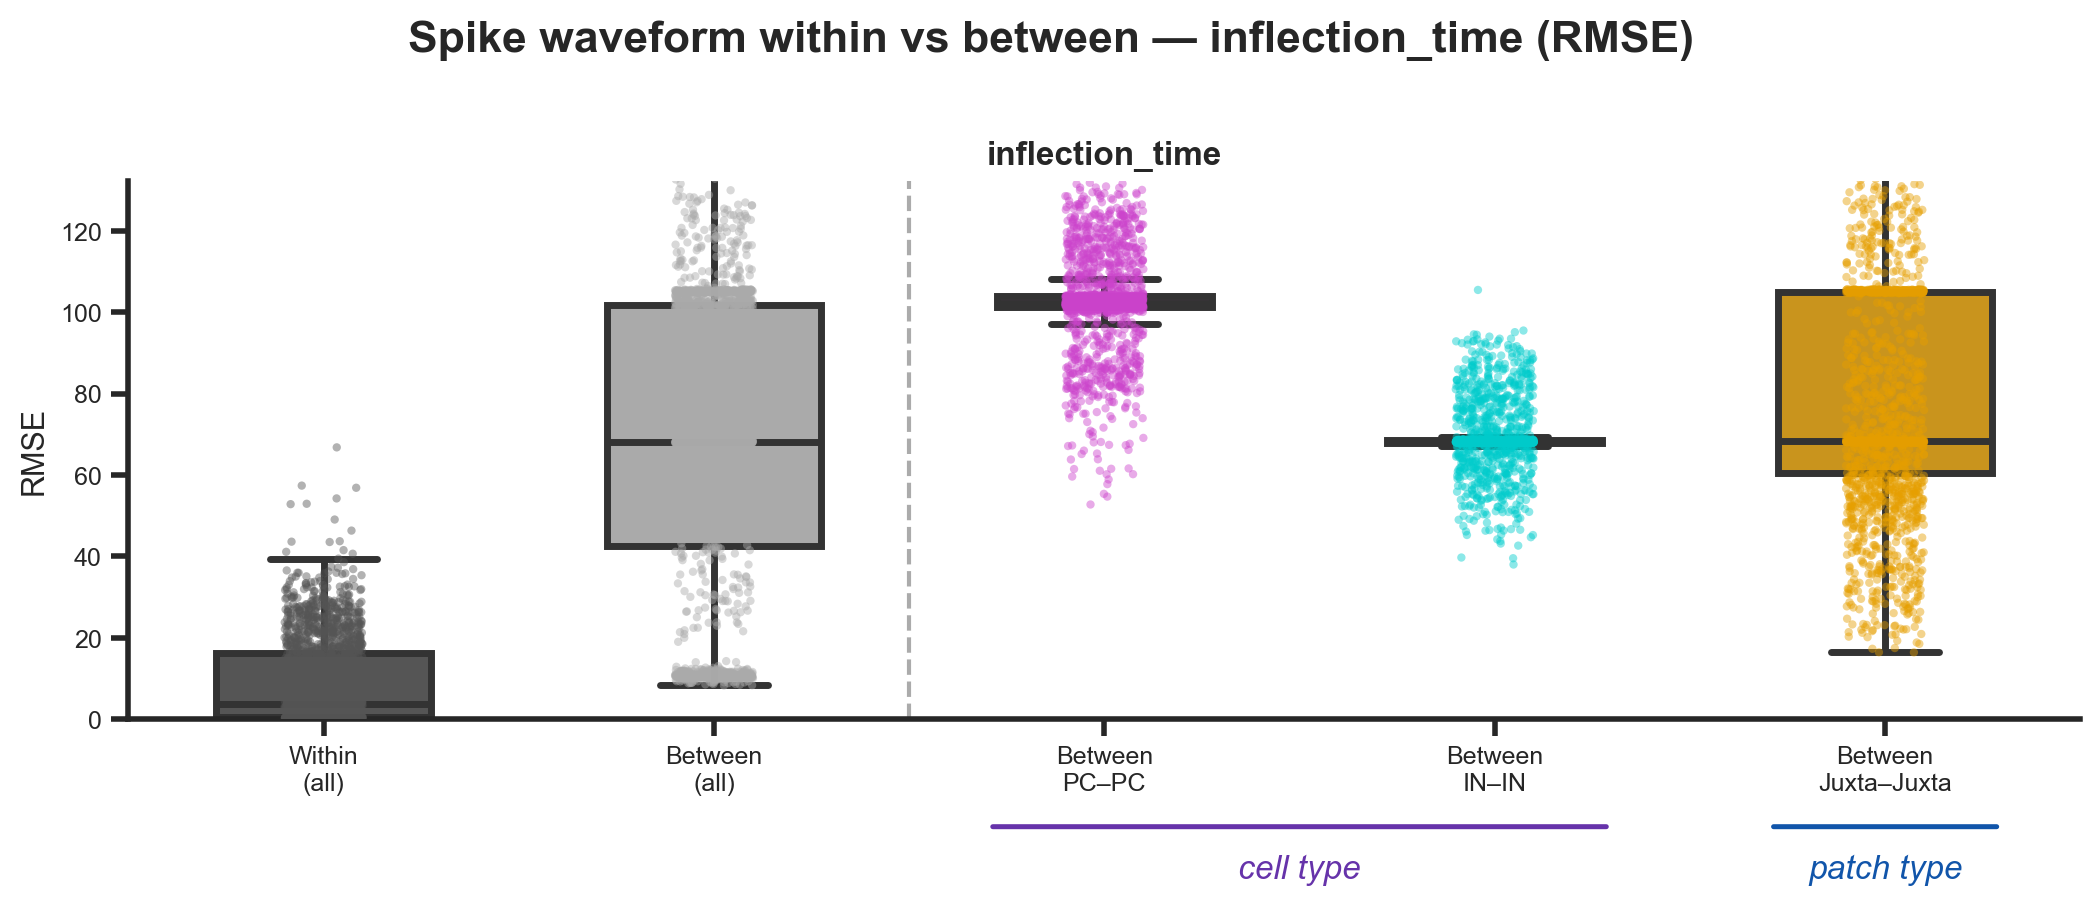

In [ ]:
plot_spike_feature_within_vs_between(CLUSTER_PKL_DIR, SPIKE_FIT_DIR, detailed=True, df_master=df_master)

## Option E — Between-cell subgroups (PC–PC, IN–IN, Juxta–Juxta, WC–WC)
Full `plot_spike_to_avg_distances` with all between-cell subgroups.
Rules out that between-cell distance is inflated by cross-cell-type comparisons.

[spike_to_avg] cache HIT — loading


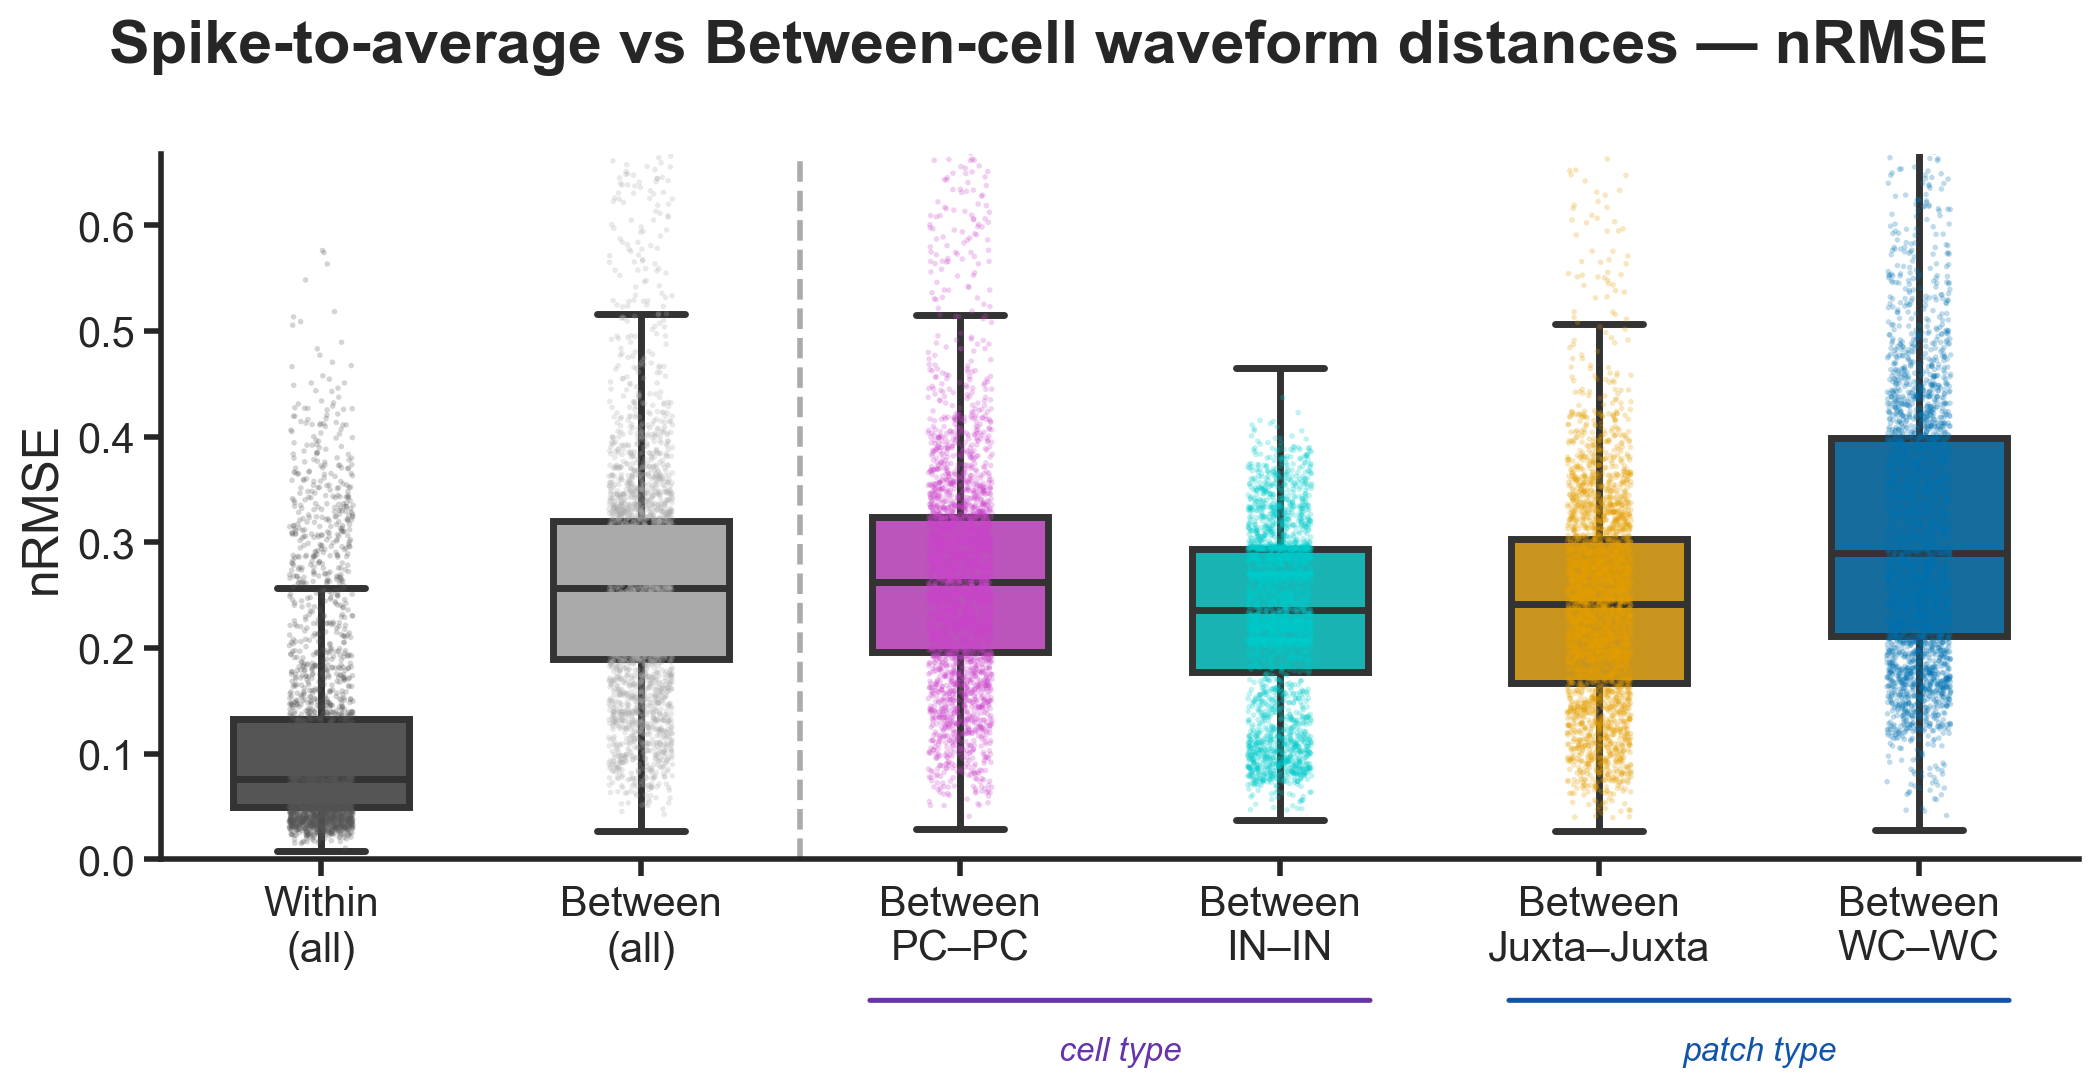


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


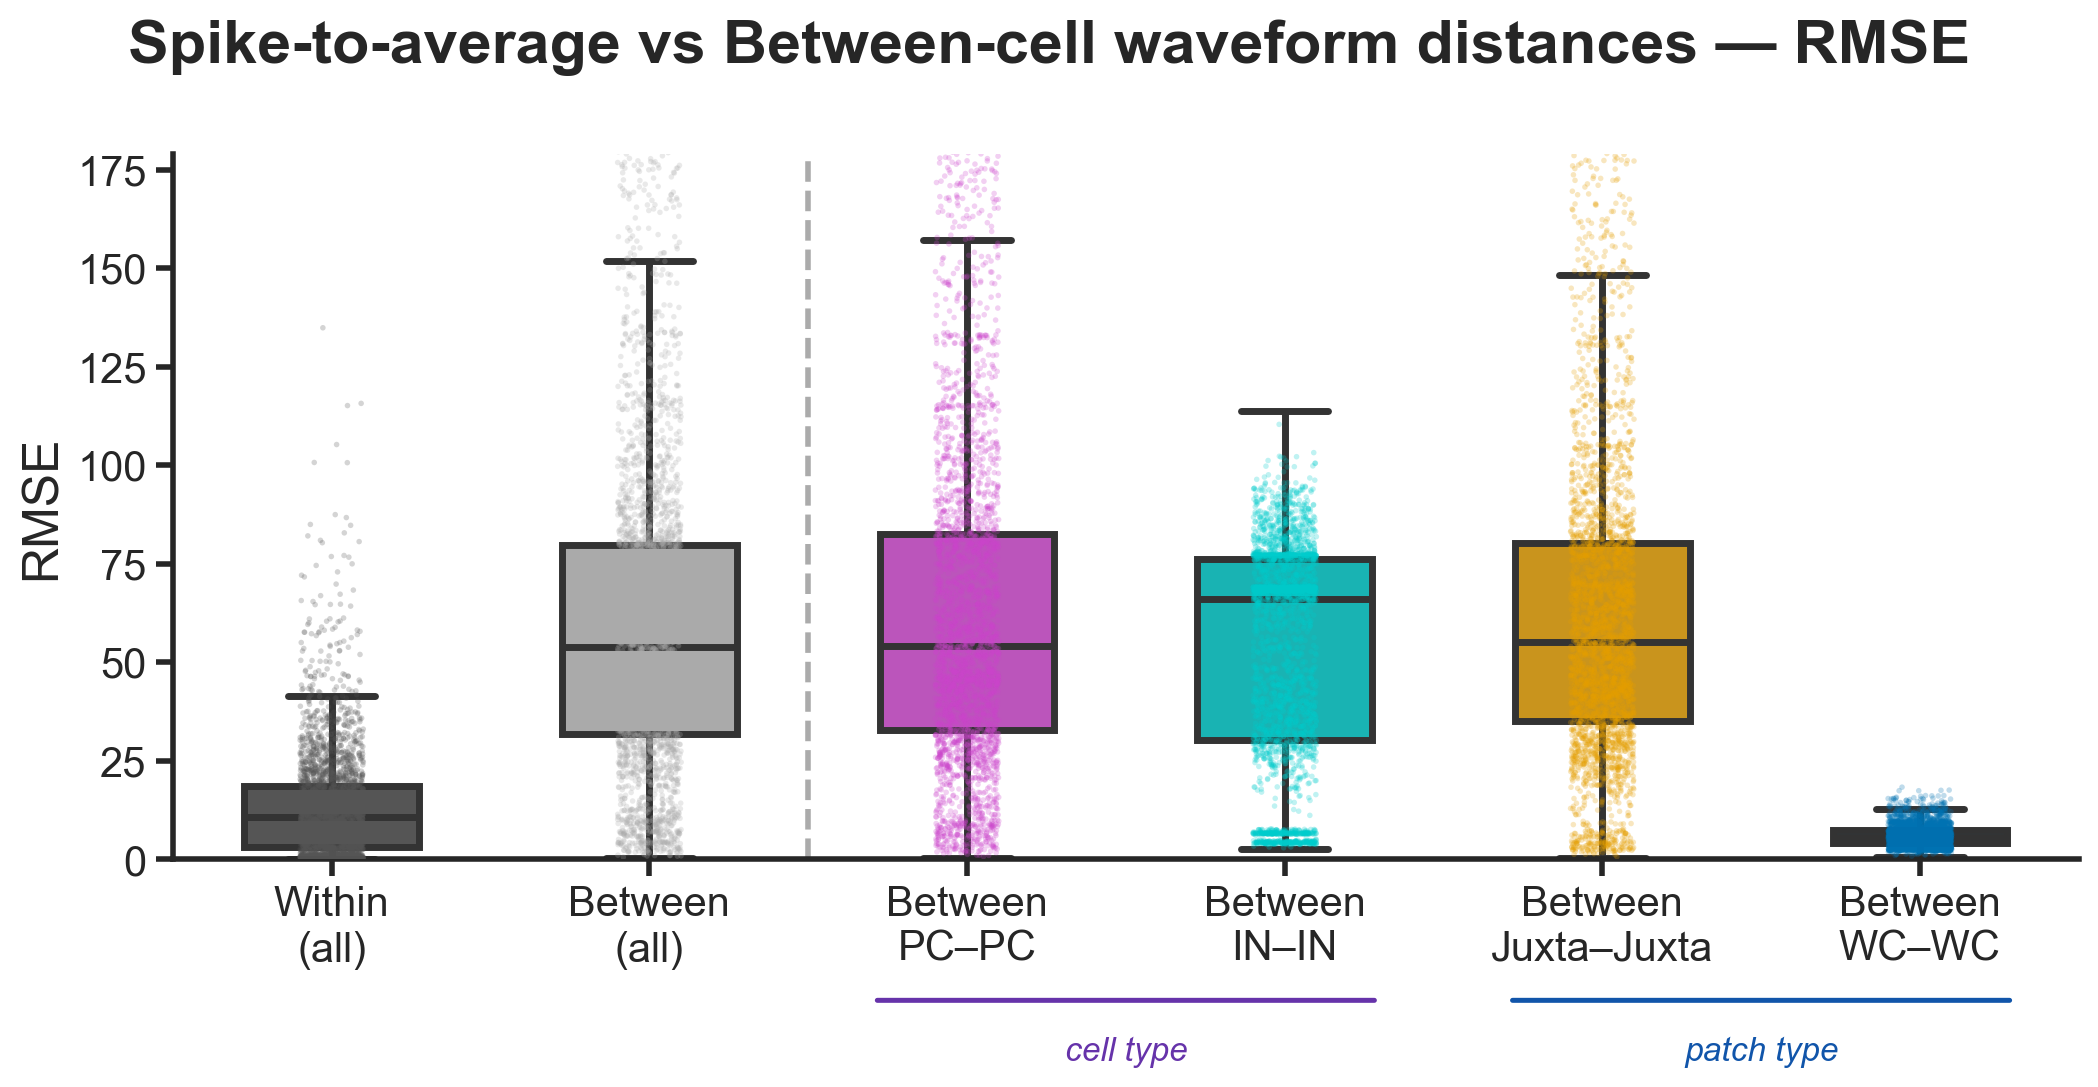


── RMSE (spike-to-avg) ──
  Within (all)          : median=10.807  IQR=[3.193, 18.527]  n=167006
  Between (all)         : median=53.757  IQR=[31.881, 79.829]  n=200000
  Between PC–PC         : median=54.194  IQR=[32.900, 82.664]  n=200000
  Between IN–IN         : median=65.950  IQR=[30.395, 76.129]  n=200000
  Between Juxta–Juxta   : median=55.177  IQR=[35.058, 80.324]  n=200000
  Between WC–WC         : median=5.766  IQR=[4.041, 7.521]  n=77752


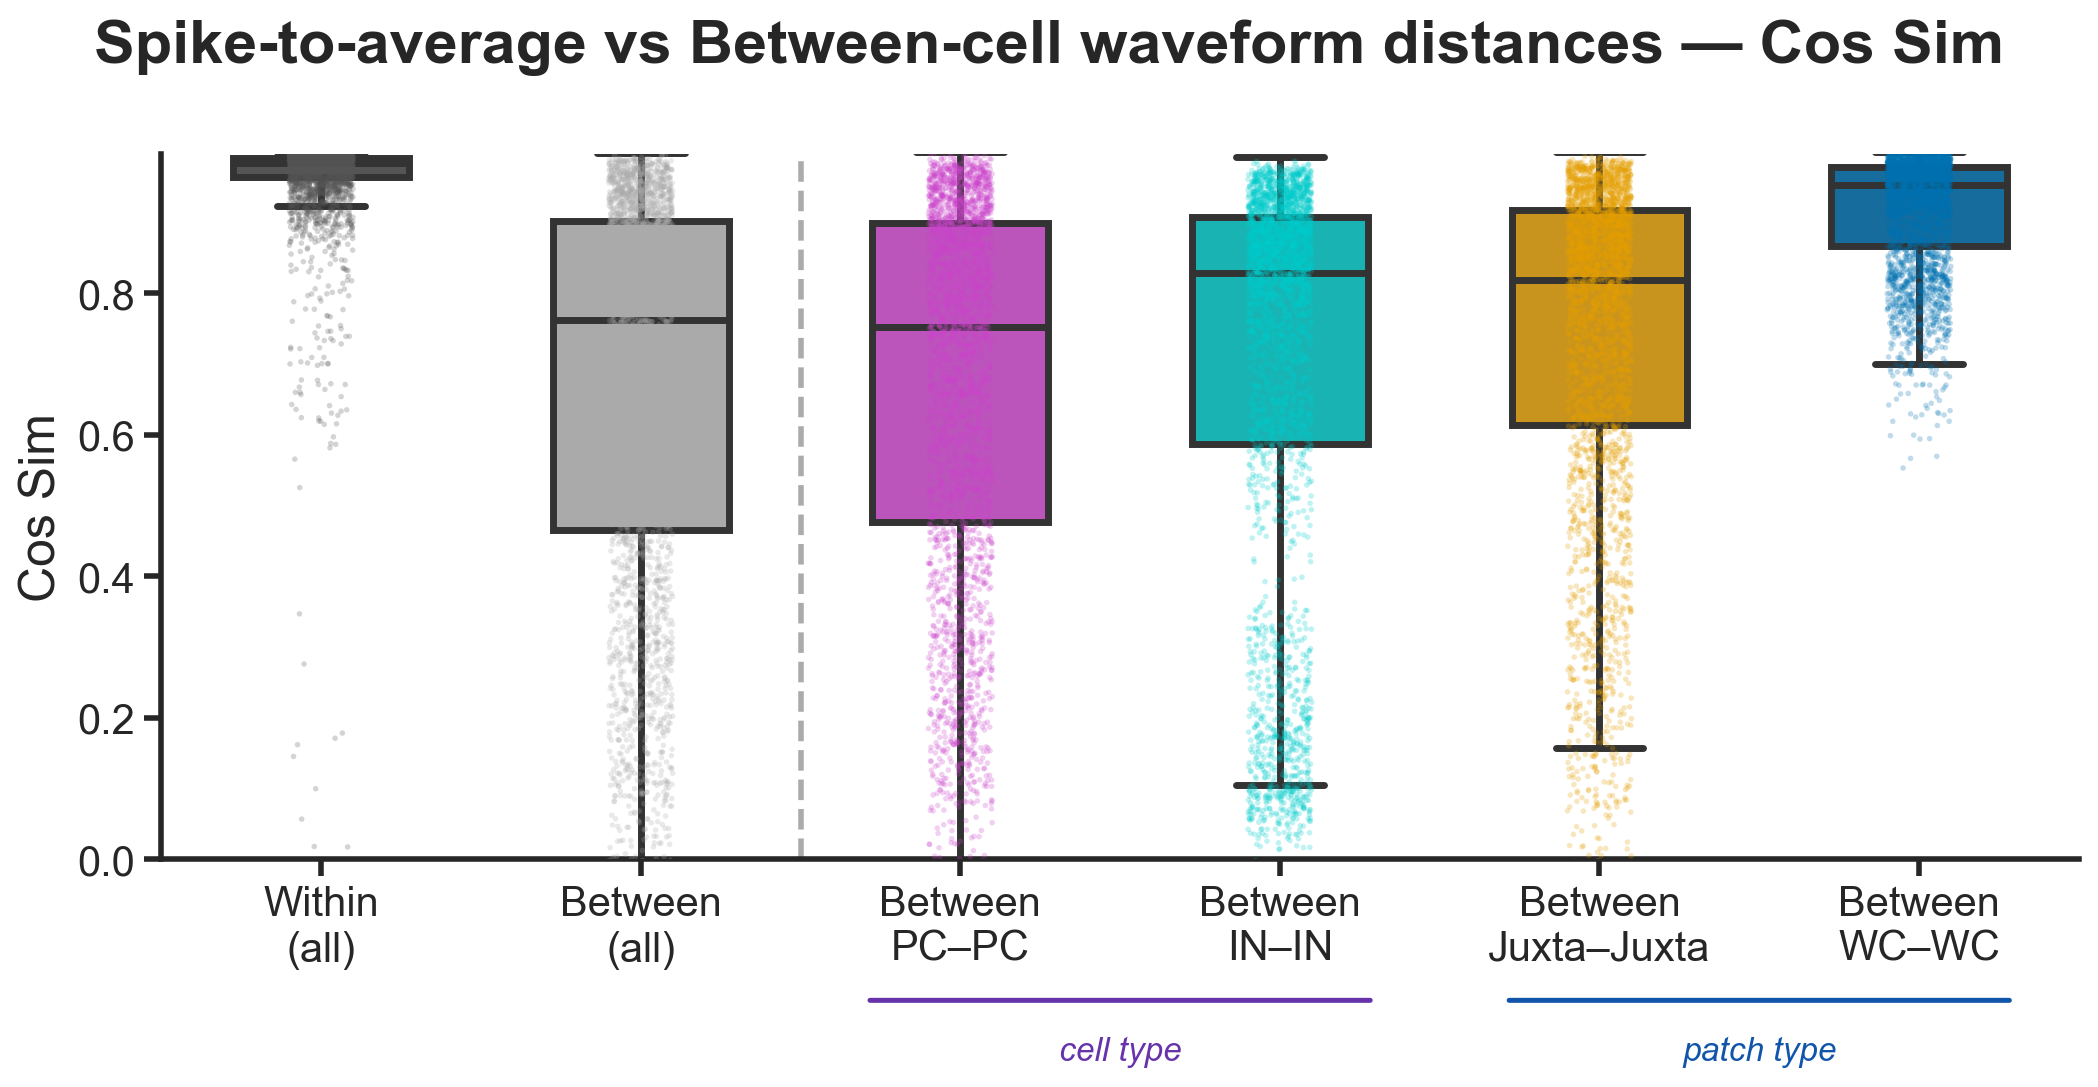


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.762  IQR=[0.465, 0.903]  n=200000
  Between PC–PC         : median=0.752  IQR=[0.477, 0.900]  n=200000
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=200000
  Between Juxta–Juxta   : median=0.819  IQR=[0.614, 0.918]  n=200000
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752


In [ ]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=CLUSTER_PKL_DIR,
    spike_fit_dir=SPIKE_FIT_DIR,
    half_win=75,
)

## Option F — nRMSE only (stripped-down main panel version)
Same sorted-dots plot as main figure Panel D but nRMSE only, no schematic inset.

[spike_to_avg] cache HIT — loading


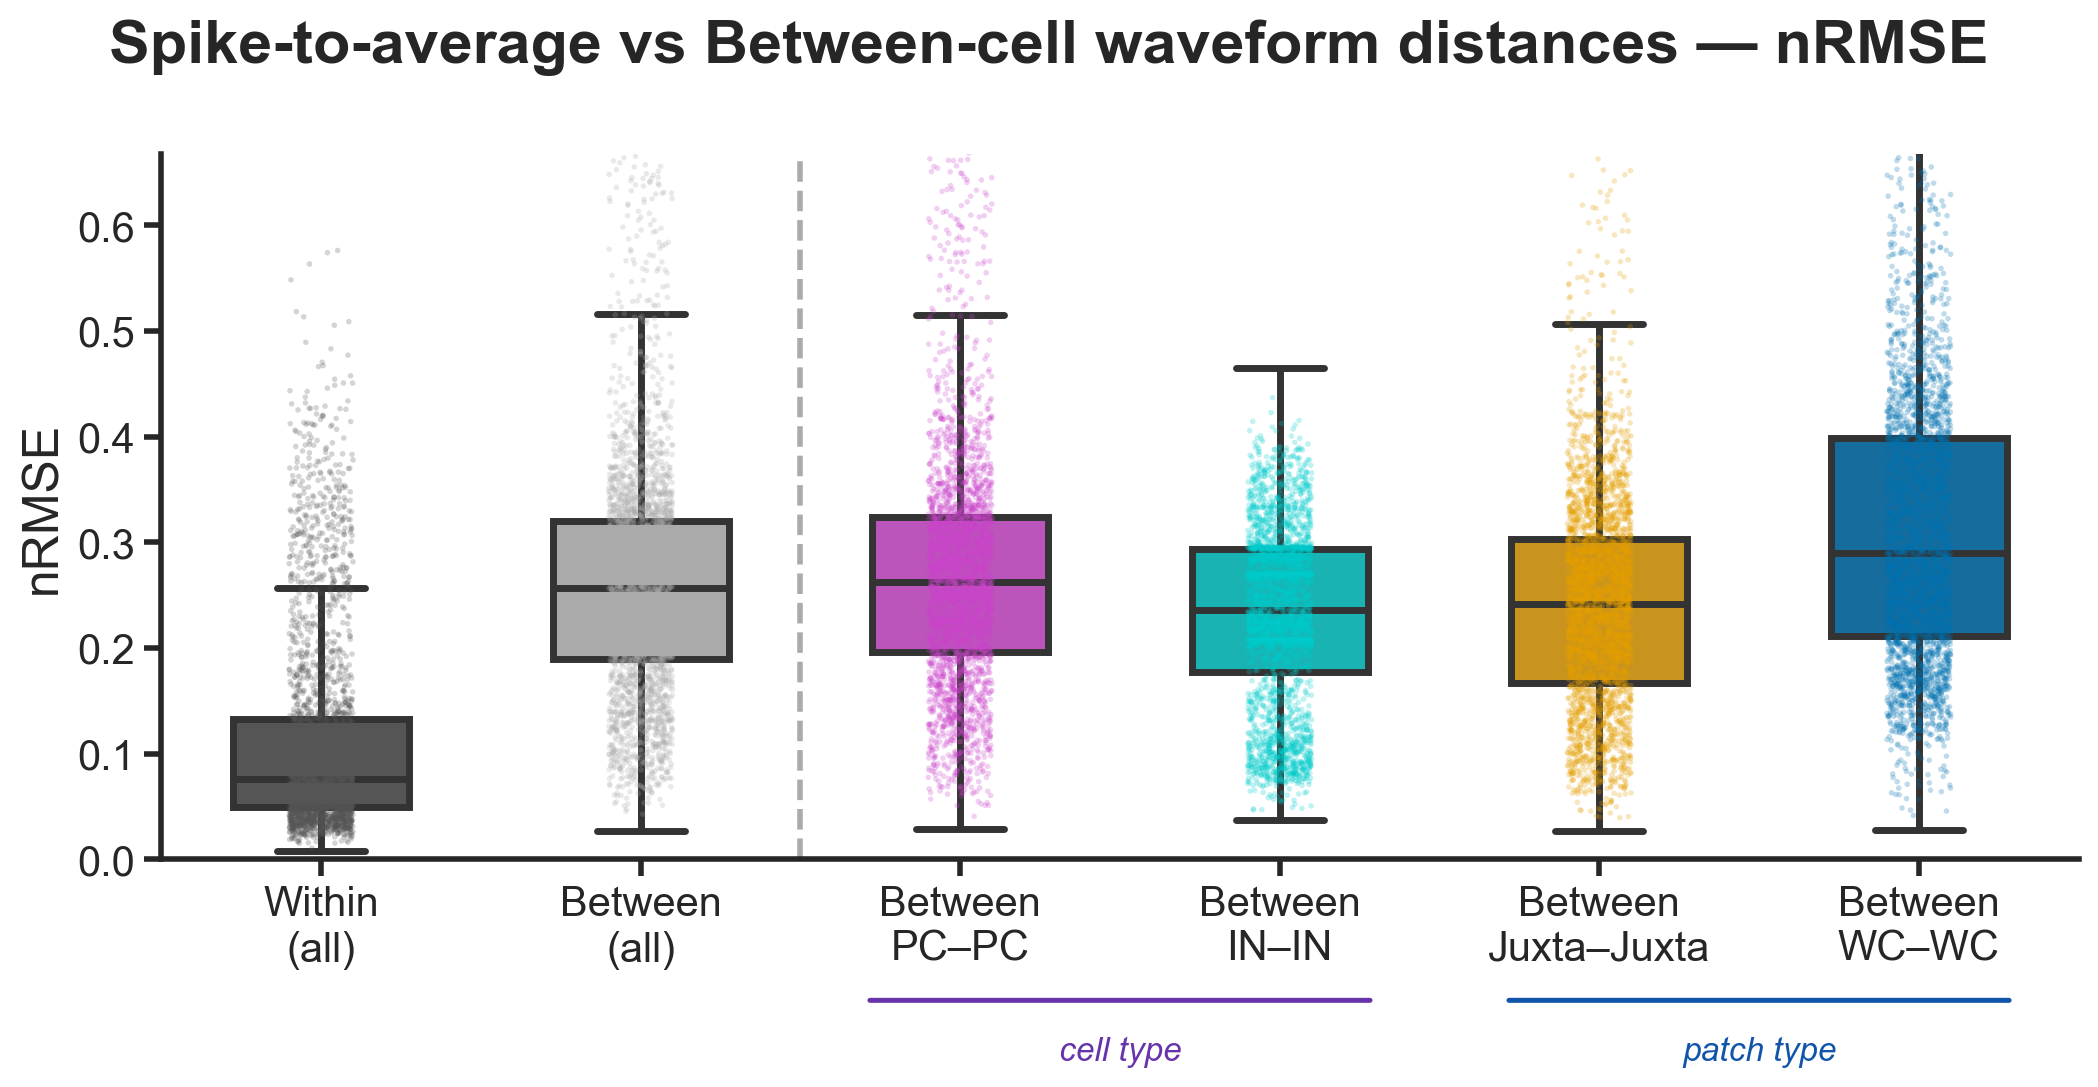


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


In [ ]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=CLUSTER_PKL_DIR,
    spike_fit_dir=SPIKE_FIT_DIR,
    half_win=75,
    metrics=['nRMSE'],
)

## Option G — Cos sim version of sorted-dots
Same as main panel but using cosine similarity instead of nRMSE.

[spike_to_avg] cache HIT — loading


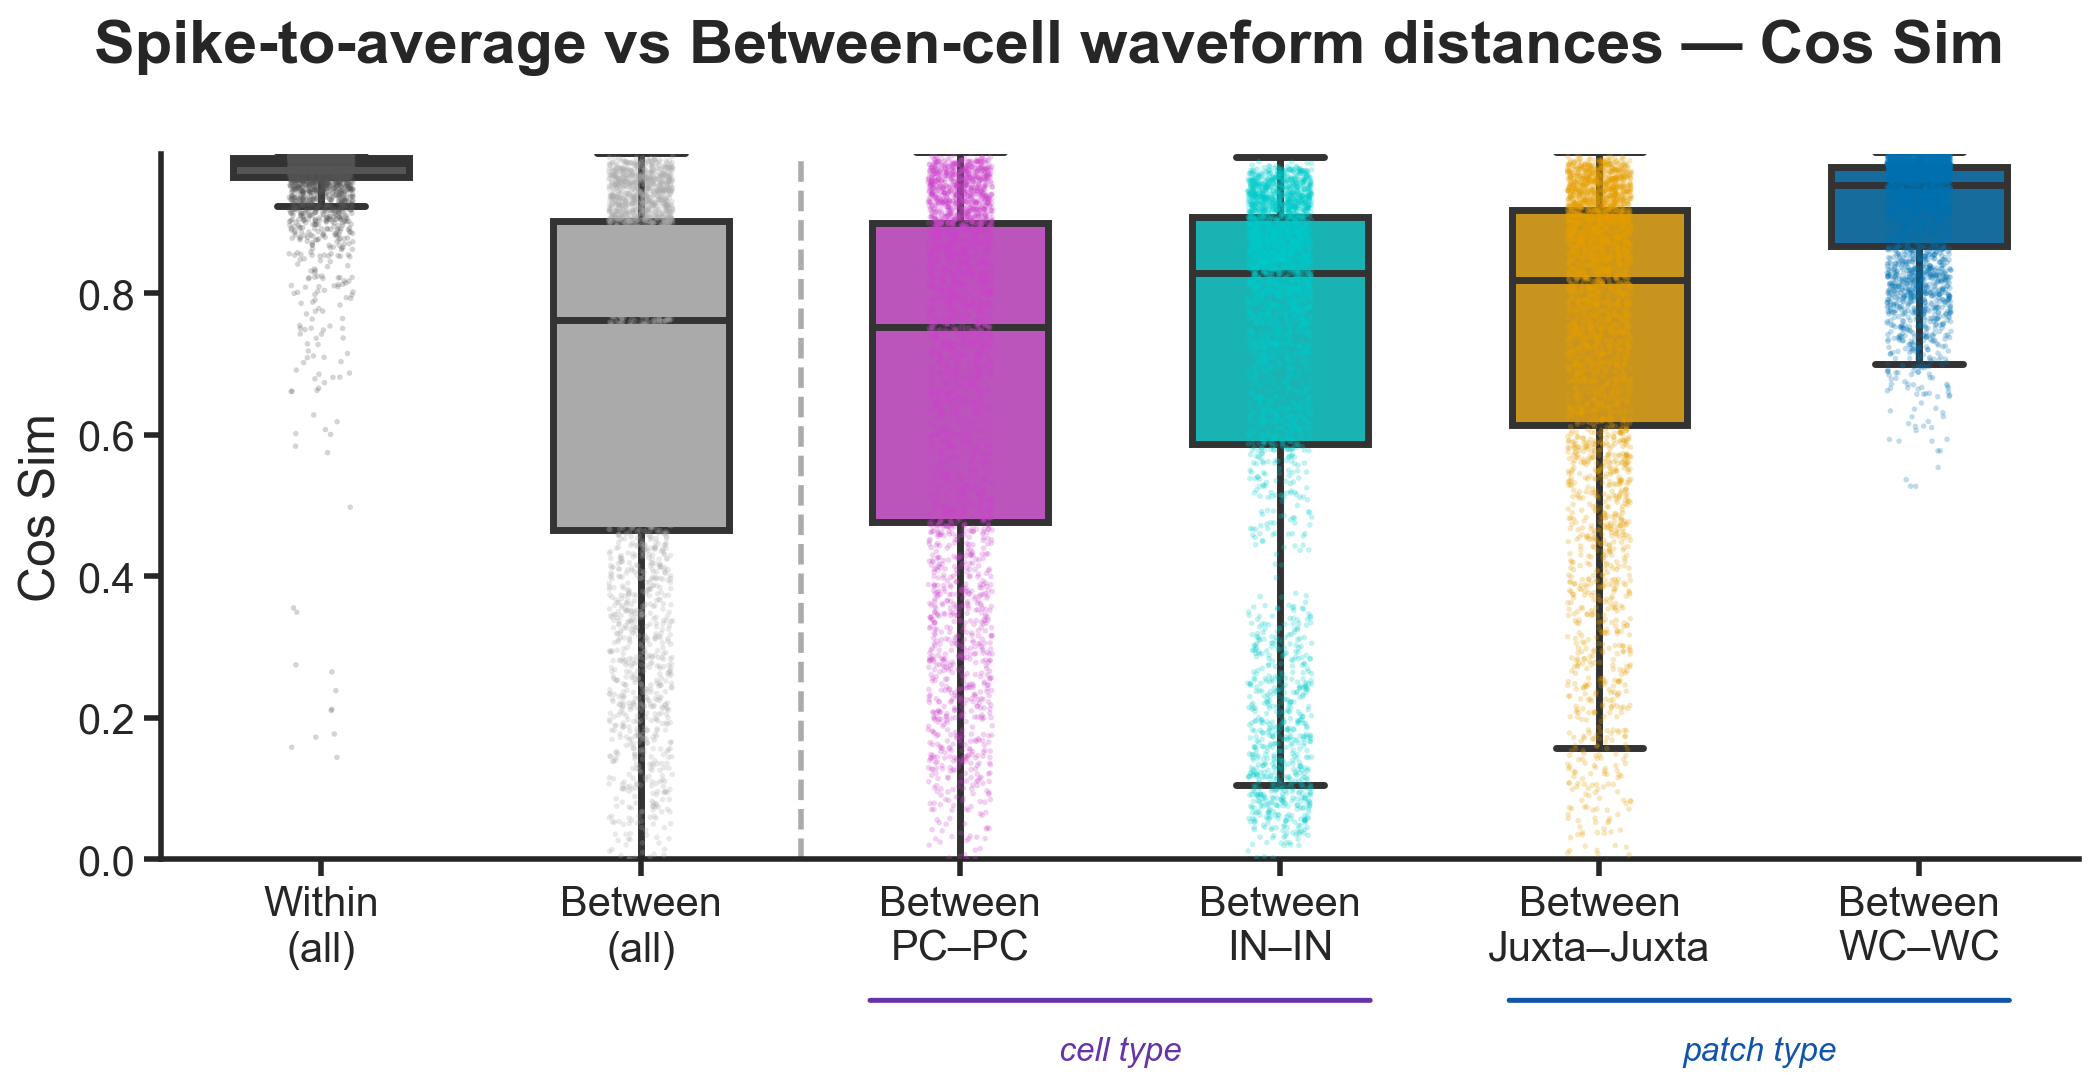


── Cos Sim (spike-to-avg) ──
  Within (all)          : median=0.984  IQR=[0.965, 0.992]  n=167006
  Between (all)         : median=0.762  IQR=[0.465, 0.903]  n=200000
  Between PC–PC         : median=0.752  IQR=[0.477, 0.900]  n=200000
  Between IN–IN         : median=0.828  IQR=[0.587, 0.908]  n=200000
  Between Juxta–Juxta   : median=0.819  IQR=[0.614, 0.918]  n=200000
  Between WC–WC         : median=0.953  IQR=[0.868, 0.979]  n=77752


In [ ]:
plot_spike_to_avg_distances(
    df_master,
    wf_dir=CLUSTER_PKL_DIR,
    spike_fit_dir=SPIKE_FIT_DIR,
    half_win=75,
    metrics=['Cos Sim'],
)

**Supplementary Figure X. Within- vs between-cell waveform distances.**

*[Caption placeholder — fill in after panel selection.]*